# Анализ и моделирование шума NDVI с использованием погодных признаков ERA5

Определить, могут ли погодные условия (данные ERA5) объяснить «физический шум» 
вегетационного индекса NDVI — отклонения сырых спутниковых значений от 
сглаженной кривой-эталона. Исследование проводит сравнительный анализ четырёх 
независимых подходов (и всех их вместе) к построению погодных признаков и двух моделей машинного 
обучения для каждой группы признаков.

> Анализ пожаров (fire) на данном этапе не проводится.


## Импорты и настройки


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from prophet import Prophet
from scipy.interpolate import PchipInterpolator, interp1d
from scipy.signal import savgol_filter
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import warnings

warnings.filterwarnings("ignore")

LANDSAT_PATH = "landsat_data_2019_2025.csv"
ERA5_HOURLY_PATH = "join_every_hour_era5_data.csv"
MERGED_PATH = "merged_landsat_era5.csv"

TEAL = "#0E9E9E"
TEAL_DARK = "#076E6E"
TEAL_LIGHT = "#A8DEDE"
ACCENT = "#E05C5C"
DARK_BG = "#F0FAFA"
COLORS_4 = ["#0E9E9E", "#E05C5C", "#F5A623", "#7B68EE"]

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": DARK_BG,
        "axes.edgecolor": TEAL_DARK,
        "axes.labelcolor": TEAL_DARK,
        "axes.grid": True,
        "grid.color": TEAL_LIGHT,
        "grid.alpha": 0.45,
        "xtick.color": TEAL_DARK,
        "ytick.color": TEAL_DARK,
        "text.color": "#1A2E2E",
        "font.family": "DejaVu Sans",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.framealpha": 0.92,
        "legend.edgecolor": TEAL_DARK,
        "figure.dpi": 110,
    }
)

## Шаг 0. Агрегация почасовых данных ERA5 до дневных значений

Landsat делает снимки нерегулярно (раз в несколько дней), тогда как ERA5 содержит 
почасовые данные. Для объединения по дате необходимо привести ERA5 к суточному 
разрешению с физически обоснованными агрегатами.


In [2]:
era5_raw = pd.read_csv(ERA5_HOURLY_PATH)
era5_raw["datetime_str_utc"] = pd.to_datetime(era5_raw["datetime_str_utc"])
era5_raw["date"] = era5_raw["datetime_str_utc"].dt.normalize()

AGG = {
    "temperature_2m": "mean",
    "skin_temperature": "mean",
    "total_precipitation_hourly": "sum",
    "surface_solar_radiation_downwards_hourly": "sum",
    "volumetric_soil_water_layer_1": "mean",
    "u_component_of_wind_10m": "mean",
    "v_component_of_wind_10m": "mean",
    "total_evaporation_hourly": "sum",
    "dewpoint_temperature_2m": "mean",
    "evaporation_from_vegetation_transpiration_hourly": "sum",
}

agg_avail = {k: v for k, v in AGG.items() if k in era5_raw.columns}
era5_daily = era5_raw.groupby(["ID", "date"], as_index=False).agg(agg_avail)

coords = era5_raw.groupby("ID")[["center_lon", "center_lat"]].first().reset_index()
era5_daily = era5_daily.merge(coords, on="ID", how="left")

print(f"Почасовых строк ERA5 : {len(era5_raw):>10,}")
print(f"Дневных строк ERA5   : {len(era5_daily):>10,}")
print(f"Уникальных ID        : {era5_daily['ID'].nunique()}")
print(
    f"Период               : {era5_daily['date'].min().date()} -> {era5_daily['date'].max().date()}"
)
era5_daily.head(3)

Почасовых строк ERA5 :    810,720
Дневных строк ERA5   :     33,780
Уникальных ID        : 15
Период               : 2019-01-01 -> 2025-03-01


,ID,date,temperature_2m,skin_temperature,total_precipitation_hourly,surface_solar_radiation_downwards_hourly,volumetric_soil_water_layer_1,u_component_of_wind_10m,v_component_of_wind_10m,total_evaporation_hourly,dewpoint_temperature_2m,evaporation_from_vegetation_transpiration_hourly,center_lon,center_lat
0,70,2019-01-01,261.611664,261.469400,1.829863e-05,7609812.0,0.370987,1.999447,-1.065345,-0.000052,247.863574,-1.862645e-09,131.518922,44.262327
1,70,2019-01-02,261.413286,261.045760,8.523463e-07,7615072.0,0.370998,1.793548,-1.059179,-0.000031,251.757376,-2.793968e-09,131.518922,44.262327
2,70,2019-01-03,261.790602,261.058092,0.000000e+00,7699332.0,0.371002,1.232733,-0.276780,-0.000024,252.117400,0.000000e+00,131.518922,44.262327


### Почему агрегация обязательна?

| Переменная | Агрегат | Физическое обоснование |
|---|---|---|
| temperature_2m, skin_temperature, dewpoint_temperature_2m | mean | Интенсивные величины; среднесуточная T — стандартная климатическая метрика |
| volumetric_soil_water_layer_1 | mean | Влажность почвы медленно меняется; суточное среднее — устойчивая оценка |
| u/v_component_of_wind_10m | mean | Вектор скорости ветра — интенсивная величина |
| total_precipitation_hourly | sum | Осадки — потоковая величина: суточная сумма = стандарт метеорологии |
| surface_solar_radiation_downwards_hourly | sum | Суточный приход солнечной энергии |
| total_evaporation_hourly, evaporation_from_vegetation_transpiration_hourly | sum | Суточный поток воды через поверхность |

## Предварительный шаг: объединение Landsat + ERA5

Алгоритм сглаживания NDVI ожидает единый CSV, содержащий как спектральные каналы 
(B2–B12), так и колонки ERA5. Поэтому мы объединяем Landsat и дневной ERA5 
по (ID, datetime_utc) через merge_asof.


In [3]:
df_landsat = pd.read_csv(LANDSAT_PATH)
df_landsat["datetime_utc"] = pd.to_datetime(df_landsat["datetime_str_utc"])
df_landsat["date"] = df_landsat["datetime_utc"].dt.normalize()

era5_daily["date"] = pd.to_datetime(era5_daily["date"])

era5_weather_cols = [
    "temperature_2m",
    "skin_temperature",
    "total_precipitation_hourly",
    "surface_solar_radiation_downwards_hourly",
    "volumetric_soil_water_layer_1",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "total_evaporation_hourly",
    "dewpoint_temperature_2m",
    "evaporation_from_vegetation_transpiration_hourly",
]

all_merged = []
for pid in sorted(df_landsat["ID"].unique()):
    left = (
        df_landsat[df_landsat["ID"] == pid]
        .sort_values("datetime_utc")
        .reset_index(drop=True)
    )
    right = (
        era5_daily[era5_daily["ID"] == pid][["date"] + era5_weather_cols]
        .sort_values("date")
        .reset_index(drop=True)
    )
    if len(right) == 0:
        for c in era5_weather_cols:
            left[c] = np.nan
        all_merged.append(left)
    else:
        m = pd.merge_asof(
            left,
            right,
            left_on="datetime_utc",
            right_on="date",
            tolerance=pd.Timedelta("1D"),
            direction="nearest",
        )
        all_merged.append(m)

merged = pd.concat(all_merged, ignore_index=True)
print(f"landsat: {df_landsat.shape}")
print(f"era5 daily: {era5_daily.shape}")
print(f"merged: {merged.shape}")
for c in era5_weather_cols:
    n_na = merged[c].isna().sum()
    print(f"  {c}: {n_na} ({100*n_na/len(merged):.1f}%)")
merged.to_csv(MERGED_PATH, index=False)
print(f"сохранено: {MERGED_PATH}")
merged.head(3)

landsat: (7782, 18)
era5 daily: (33780, 14)
merged: (7782, 29)
  temperature_2m: 0 (0.0%)
  skin_temperature: 0 (0.0%)
  total_precipitation_hourly: 0 (0.0%)
  surface_solar_radiation_downwards_hourly: 0 (0.0%)
  volumetric_soil_water_layer_1: 0 (0.0%)
  u_component_of_wind_10m: 0 (0.0%)
  v_component_of_wind_10m: 0 (0.0%)
  total_evaporation_hourly: 0 (0.0%)
  dewpoint_temperature_2m: 0 (0.0%)
  evaporation_from_vegetation_transpiration_hourly: 0 (0.0%)
сохранено: merged_landsat_era5.csv


,ID,center_lon,center_lat,datetime_str_utc,satellite,B2,B3,B4,B5,B6,...,temperature_2m,skin_temperature,total_precipitation_hourly,surface_solar_radiation_downwards_hourly,volumetric_soil_water_layer_1,u_component_of_wind_10m,v_component_of_wind_10m,total_evaporation_hourly,dewpoint_temperature_2m,evaporation_from_vegetation_transpiration_hourly
0,70,131.518922,44.262327,2019-01-03 02:24,Sentinel-2,592.0,907.0,1510.0,1713.0,1834.0,...,261.790602,261.058092,0.0,7699332.0,0.371002,1.232733,-0.276780,-0.000024,252.11740,0.000000e+00
1,70,131.518922,44.262327,2019-01-05 02:15,Sentinel-2,725.0,981.0,1532.0,1800.0,1884.0,...,261.241972,260.983949,0.0,7719316.0,0.371002,1.850841,-1.192746,-0.000034,250.49593,-4.656613e-09
2,70,131.518922,44.262327,2019-01-05 02:15,Sentinel-2,764.0,999.0,1538.0,1830.0,1914.0,...,261.241972,260.983949,0.0,7719316.0,0.371002,1.850841,-1.192746,-0.000034,250.49593,-4.656613e-09


## Часть 1. Алгоритм сглаживания NDVI (НЕ МЕНЯТЬ)

Дословный код из работы Влада и Миши. Алгоритм включает:
1. Зимний базовый уровень (NDVI = 0.10 для ноября–апреля)
2. Фильтр Prophet (удаление аномальных значений)
3. Удаление близких точек (порог 0.10 * std, max_gap 7 дней)
4. Перенос локальных минимумов (порог 0.05 * std)
5. PCHIP-интерполяция на сетке 5 дней
6. Верхняя огибающая Savitzky-Golay (window=11, polyorder=2, 3 итерации)


In [4]:
APPLY_WINTER_BASELINE = True
WINTER_BASELINE_VALUE = 0.10
APPLY_PROPHET_FILTER = True
PROPHET_LEVEL_MIN = 0.23
PROPHET_LEVEL_MAX = 0.35
APPLY_REMOVE_CLOSE_POINTS = True
REMOVE_CLOSE_THRESHOLD = 0.10
REMOVE_CLOSE_MAX_GAP_DAYS = 7
APPLY_TRANSFER_LOCAL_MINIMA = True
LOCAL_MINIMA_THRESHOLD = 0.05
INTERP_KIND = "pchip"
GRID_STEP_DAYS = 5
APPLY_FINAL_SMOOTHING = True
FINAL_SAVGOL_WINDOW = 11
FINAL_SAVGOL_POLYORDER = 2


def load_ndvi_data(file_path, point_id=None):
    df = pd.read_csv(file_path)
    if point_id is not None:
        df = df[df["ID"] == point_id].copy()
    df["NDVI"] = (df["B8"] - df["B4"]) / (df["B8"] + df["B4"])
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["NDVI"])
    df = df[df["NDVI"].between(-1, 1)].copy()
    df["datetime_utc"] = pd.to_datetime(df["datetime_str_utc"])
    return df.sort_values("datetime_utc").reset_index(drop=True)


def apply_winter_baseline(df, winter_value=0.30, enabled=True):
    if not enabled:
        return df.copy()
    res = df.copy()
    m, d = res["datetime_utc"].dt.month, res["datetime_utc"].dt.day
    winter = ((m == 11) & (d >= 20)) | (m == 12) | (m <= 3) | ((m == 4) & (d <= 10))
    res.loc[winter, "NDVI"] = float(winter_value)
    return res


def process_ndvi_prophet_filter(df, level_min=0.20, level_max=0.30, enabled=True):
    if not enabled or len(df) < 5:
        return df.copy(), pd.DataFrame(), pd.DataFrame()
    m = Prophet(
        yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False
    )
    pdf = df.rename(columns={"datetime_utc": "ds", "NDVI": "y"})
    m.fit(pdf)
    forecast = m.predict(pdf[["ds"]])
    yhat = forecast["yhat"].values
    std = df["NDVI"].std()
    lower, upper = yhat - level_min * std, yhat + level_max * std
    mask = (df["NDVI"] >= lower) & (df["NDVI"] <= upper)
    removed = df[~mask].copy()
    curve = pd.DataFrame(
        {
            "datetime_utc": df["datetime_utc"],
            "yhat": yhat,
            "lower": lower,
            "upper": upper,
        }
    )
    return df[mask].copy(), removed, curve


def remove_close_points(df, threshold=0.10, max_gap_days=7, enabled=True):
    if not enabled or len(df) < 3:
        return df.copy(), pd.DataFrame()
    df = df.sort_values("datetime_utc").reset_index(drop=True)
    ndvi = df["NDVI"].values
    std = df["NDVI"].std()
    diff_p = np.abs(np.diff(ndvi, prepend=ndvi[0]))
    diff_n = np.abs(np.diff(ndvi, append=ndvi[-1]))
    gap_p = df["datetime_utc"].diff().dt.total_seconds().values / 86400
    gap_n = df["datetime_utc"].diff(-1).dt.total_seconds().abs().values / 86400
    mask = (
        (gap_p <= max_gap_days)
        & (gap_n <= max_gap_days)
        & (diff_p < threshold * std)
        & (diff_n < threshold * std)
    )
    return df[~mask].copy(), df[mask].assign(removed_stage="close_points")


def transfer_local_minima(df, threshold=0.05, enabled=True):
    if not enabled or len(df) < 3:
        return df.copy(), pd.DataFrame()
    df = df.sort_values("datetime_utc").reset_index(drop=True)
    ndvi = df["NDVI"].values
    delta = threshold * df["NDVI"].std()
    is_min = (ndvi[1:-1] < ndvi[:-2] - delta) & (ndvi[1:-1] < ndvi[2:] - delta)
    mask = np.concatenate([[False], is_min, [False]])
    return df[~mask].copy(), df[mask].assign(removed_stage="local_minima")


def interpolate_ndvi(kept_df, interp_kind="pchip", grid_step_days=5):
    if len(kept_df) < 2:
        raise ValueError("Мало точек.")
    clean = (
        kept_df.groupby("datetime_utc", as_index=False)["NDVI"]
        .max()
        .sort_values("datetime_utc")
    )
    t_start = clean["datetime_utc"].min()
    grid = pd.date_range(
        t_start, clean["datetime_utc"].max(), freq=f"{grid_step_days}D"
    )
    x_have = (clean["datetime_utc"] - t_start).dt.total_seconds().values / 86400.0
    x_want = (grid - t_start).total_seconds().values / 86400.0
    if interp_kind == "pchip":
        f = PchipInterpolator(x_have, clean["NDVI"].values)
    else:
        f = interp1d(
            x_have, clean["NDVI"].values, kind=interp_kind, fill_value="extrapolate"
        )
    return pd.DataFrame(
        {"datetime_utc": grid, "NDVI_approx": f(x_want).astype(np.float32)}
    )


def apply_upper_envelope(df_interp, iterations=4, window=11, polyorder=2):
    res = df_interp.copy()
    y_raw = res["NDVI_approx"].values
    y_smooth = savgol_filter(y_raw, window, polyorder)
    for _ in range(iterations):
        mask = y_raw > y_smooth
        y_smooth[mask] = y_raw[mask] * 0.8 + y_smooth[mask] * 0.2
        y_smooth = savgol_filter(y_smooth, window, polyorder)
    res["NDVI_smooth"] = y_smooth
    return res


def build_smooth_curve(file_path, point_id):
    df_raw = load_ndvi_data(file_path, point_id=point_id)
    df_step = apply_winter_baseline(
        df_raw, WINTER_BASELINE_VALUE, APPLY_WINTER_BASELINE
    )
    df_step, rem_p, curve_p = process_ndvi_prophet_filter(
        df_step, PROPHET_LEVEL_MIN, PROPHET_LEVEL_MAX, APPLY_PROPHET_FILTER
    )
    df_step, rem_c = remove_close_points(
        df_step,
        REMOVE_CLOSE_THRESHOLD,
        REMOVE_CLOSE_MAX_GAP_DAYS,
        APPLY_REMOVE_CLOSE_POINTS,
    )
    df_final, rem_l = transfer_local_minima(
        df_step, LOCAL_MINIMA_THRESHOLD, APPLY_TRANSFER_LOCAL_MINIMA
    )
    approx = interpolate_ndvi(df_final, INTERP_KIND, GRID_STEP_DAYS)
    if APPLY_FINAL_SMOOTHING:
        approx = apply_upper_envelope(
            approx,
            iterations=3,
            window=FINAL_SAVGOL_WINDOW,
            polyorder=FINAL_SAVGOL_POLYORDER,
        )
    else:
        approx["NDVI_smooth"] = approx["NDVI_approx"]
    return df_raw, approx


print("функции сглаживания загружены")

функции сглаживания загружены


### Цикл по ID: построение сглаженной кривой


In [5]:
LANDSAT_PATH = MERGED_PATH

df_full = pd.read_csv(LANDSAT_PATH)
df_full["datetime_utc"] = pd.to_datetime(df_full["datetime_str_utc"])
all_ids = sorted(df_full["ID"].unique())
print(f"уникальных ID: {len(all_ids)} -> {all_ids}")

all_records = []

for pid in all_ids:
    print(f"  обработка ID={pid}...", end=" ")
    try:
        df_raw, approx = build_smooth_curve(LANDSAT_PATH, pid)
        df_raw_clean = df_raw[["datetime_utc", "NDVI"]].rename(
            columns={"NDVI": "NDVI_raw"}
        )
        df_raw_clean = df_raw_clean.sort_values("datetime_utc").reset_index(drop=True)
        approx_clean = (
            approx[["datetime_utc", "NDVI_smooth"]]
            .sort_values("datetime_utc")
            .reset_index(drop=True)
        )
        merged = pd.merge_asof(
            df_raw_clean,
            approx_clean,
            on="datetime_utc",
            tolerance=pd.Timedelta("3D"),
            direction="nearest",
        )
        merged["ID"] = pid

        era5_cols = [
            c
            for c in df_full.columns
            if c
            not in [
                "B2",
                "B3",
                "B4",
                "B5",
                "B6",
                "B7",
                "B8",
                "B8A",
                "B11",
                "B12",
                "satellite",
                "datetime_str_utc",
                "fire",
                "date",
            ]
        ]
        df_era5 = (
            df_full[df_full["ID"] == pid][era5_cols]
            .copy()
            .sort_values("datetime_utc")
            .reset_index(drop=True)
        )
        merged = pd.merge_asof(
            merged.sort_values("datetime_utc"),
            df_era5.sort_values("datetime_utc"),
            on="datetime_utc",
            by="ID",
            tolerance=pd.Timedelta("3D"),
            direction="nearest",
        )

        all_records.append(merged)
        print(f"OK ({len(merged)} строк)")
    except Exception as e:
        print(f"ОШИБКА: {e}")

ndvi_all = pd.concat(all_records, ignore_index=True)
print(f"\nитоговый датасет: {ndvi_all.shape[0]} строк, {ndvi_all.shape[1]} столбцов")
ndvi_all.head()

уникальных ID: 15 -> [np.int64(70), np.int64(71), np.int64(72), np.int64(84), np.int64(183), np.int64(184), np.int64(185), np.int64(186), np.int64(187), np.int64(296), np.int64(307), np.int64(312), np.int64(316), np.int64(319), np.int64(328)]
  обработка ID=70... 

18:45:02 - cmdstanpy - INFO - Chain [1] start processing
18:45:02 - cmdstanpy - INFO - Chain [1] done processing


OK (468 строк)
  обработка ID=71... 

18:45:03 - cmdstanpy - INFO - Chain [1] start processing
18:45:03 - cmdstanpy - INFO - Chain [1] done processing


OK (437 строк)
  обработка ID=72... 

...

18:45:08 - cmdstanpy - INFO - Chain [1] start processing
18:45:08 - cmdstanpy - INFO - Chain [1] done processing


OK (827 строк)
  обработка ID=328... 

18:45:09 - cmdstanpy - INFO - Chain [1] start processing
18:45:09 - cmdstanpy - INFO - Chain [1] done processing


OK (449 строк)

итоговый датасет: 7782 строк, 18 столбцов


,datetime_utc,NDVI_raw,NDVI_smooth,ID,center_lon,center_lat,date_x,date_y,temperature_2m,skin_temperature,total_precipitation_hourly,surface_solar_radiation_downwards_hourly,volumetric_soil_water_layer_1,u_component_of_wind_10m,v_component_of_wind_10m,total_evaporation_hourly,dewpoint_temperature_2m,evaporation_from_vegetation_transpiration_hourly
0,2019-01-03 02:24:00,0.238911,0.099990,70,131.518922,44.262327,2019-01-03,2019-01-03,261.790602,261.058092,0.000000,7699332.0,0.371002,1.232733,-0.276780,-0.000024,252.117400,0.000000e+00
1,2019-01-05 02:15:00,0.253047,0.099990,70,131.518922,44.262327,2019-01-05,2019-01-05,261.241972,260.983949,0.000000,7719316.0,0.371002,1.850841,-1.192746,-0.000034,250.495930,-4.656613e-09
2,2019-01-05 02:15:00,0.252309,0.099990,70,131.518922,44.262327,2019-01-05,2019-01-05,261.241972,260.983949,0.000000,7719316.0,0.371002,1.850841,-1.192746,-0.000034,250.495930,-4.656613e-09
3,2019-01-10 02:15:00,0.248632,0.099997,70,131.518922,44.262327,2019-01-10,2019-01-10,265.401721,265.035859,0.000001,8081696.0,0.371058,1.739161,-1.091794,-0.000040,254.939256,-2.793968e-09
4,2019-01-10 02:15:00,0.246973,0.099997,70,131.518922,44.262327,2019-01-10,2019-01-10,265.401721,265.035859,0.000001,8081696.0,0.371058,1.739161,-1.091794,-0.000040,254.939256,-2.793968e-09


## Часть 2. Анализ шума NDVI

Шум определяется как разность между сырым и сглаженным значениями NDVI:
**noise = NDVI_raw - NDVI_smooth**
Положительные значения означают, что сырой NDVI выше сглаженного (отклонение вверх),
отрицательные — ниже (отклонение вниз).


In [6]:
ndvi_all["noise"] = ndvi_all["NDVI_raw"] - ndvi_all["NDVI_smooth"]

print("статистики шума (NDVI_raw - NDVI_smooth):")
print(ndvi_all["noise"].describe())
print(f"\nмедиана:   {ndvi_all['noise'].median():.4f}")
print(
    f"IQR:       {(ndvi_all['noise'].quantile(0.75) - ndvi_all['noise'].quantile(0.25)):.4f}"
)
print(f"пропуски:  {ndvi_all['noise'].isna().sum()} из {len(ndvi_all)}")

# Процент наблюдений с шумом > 0.05 (значимый шум)
significant = (ndvi_all["noise"].abs() > 0.05).sum()
print(
    f"\nнаблюдений с |noise| > 0.05: {significant} ({100*significant/len(ndvi_all):.1f}%)"
)

статистики шума (NDVI_raw - NDVI_smooth):
count    7773.000000
mean        0.035307
std         0.124685
min        -0.408583
25%        -0.035657
50%         0.003931
75%         0.094537
max         0.752503
Name: noise, dtype: float64

медиана:   0.0039
IQR:       0.1302
пропуски:  9 из 7782

наблюдений с |noise| > 0.05: 4062 (52.2%)


### Визуализация шума


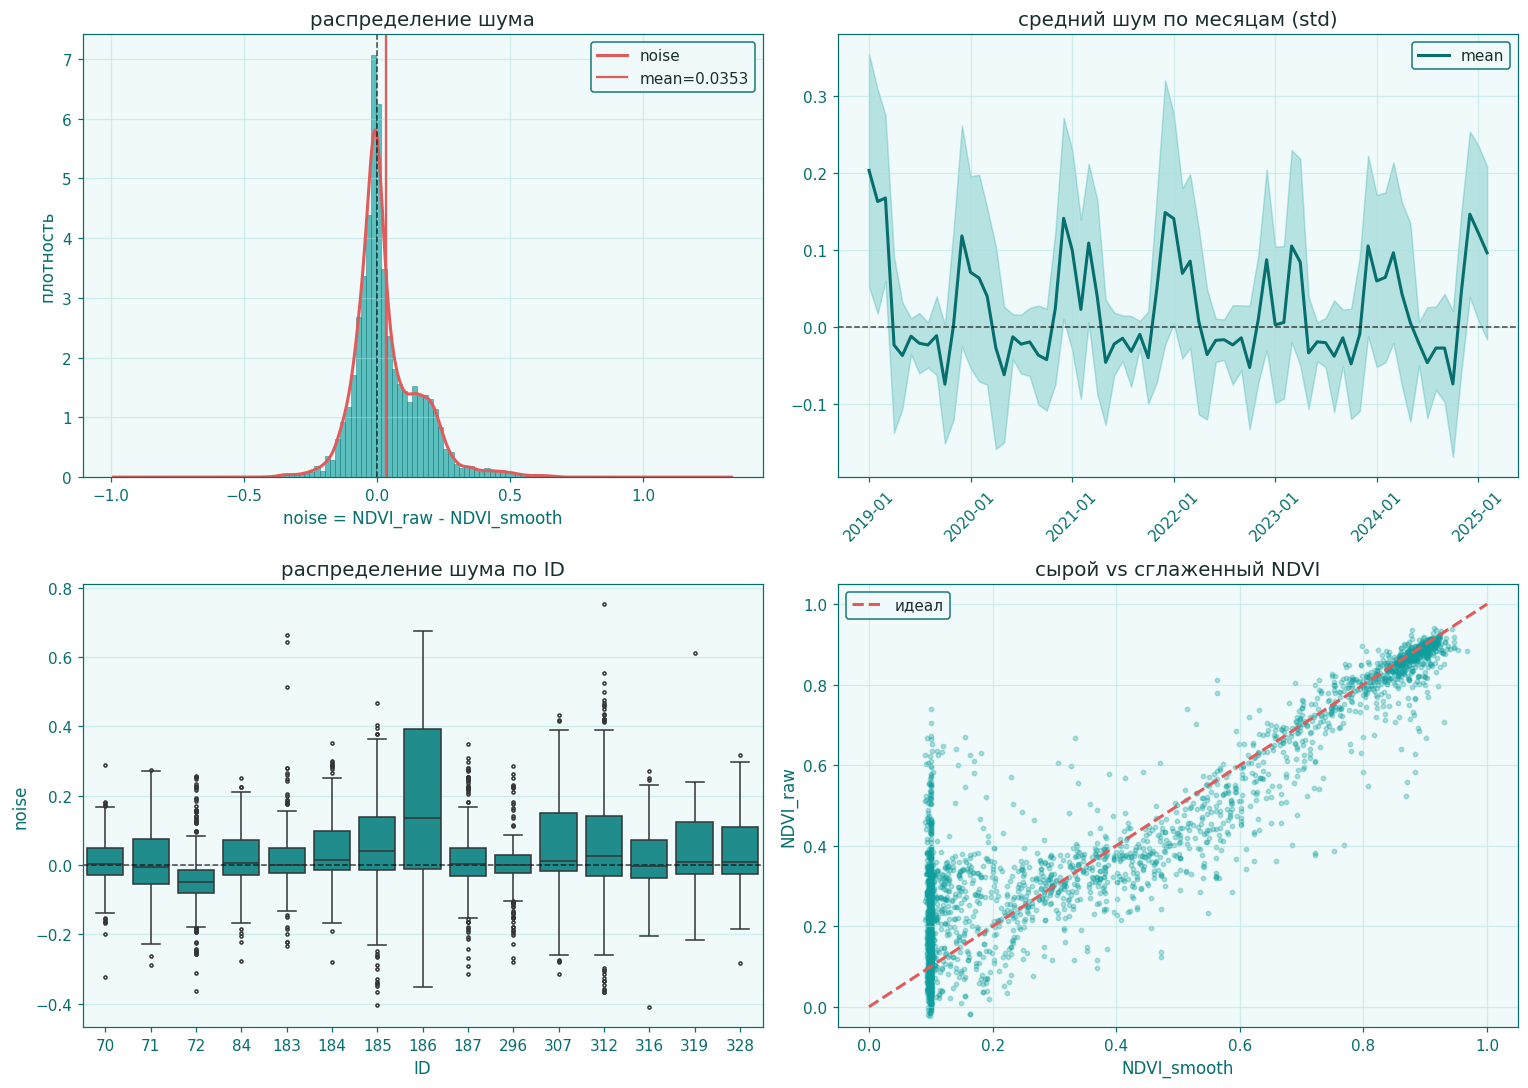

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) гистограмма шума
ax = axes[0, 0]
noise_valid = ndvi_all["noise"].dropna()
ax.hist(
    noise_valid,
    bins=60,
    density=True,
    alpha=0.65,
    color=TEAL,
    edgecolor=TEAL_DARK,
    linewidth=0.4,
)
noise_valid.plot.kde(ax=ax, color=ACCENT, linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(
    noise_valid.mean(),
    color=ACCENT,
    linestyle="-",
    linewidth=1.5,
    label=f"mean={noise_valid.mean():.4f}",
)
ax.set_xlabel("noise = NDVI_raw - NDVI_smooth")
ax.set_ylabel("плотность")
ax.set_title("распределение шума")
ax.legend(loc="best")

# 2) шум по месяцам
ax = axes[0, 1]
ndvi_all["month"] = ndvi_all["datetime_utc"].dt.to_period("M")
monthly = ndvi_all.groupby("month")["noise"].agg(["mean", "std", "count"])
monthly.index = monthly.index.to_timestamp()
ax.fill_between(
    monthly.index,
    monthly["mean"] - monthly["std"],
    monthly["mean"] + monthly["std"],
    alpha=0.25,
    color=TEAL,
)
ax.plot(monthly.index, monthly["mean"], color=TEAL_DARK, linewidth=2, label="mean")
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("средний шум по месяцам (std)")
ax.legend(loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

# 3) boxplot по ID
ax = axes[1, 0]
box_ids = sorted(ndvi_all["ID"].unique())
box_data = ndvi_all[ndvi_all["ID"].isin(box_ids)]
sns.boxplot(data=box_data, x="ID", y="noise", ax=ax, color=TEAL, fliersize=2)
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("распределение шума по ID")
ax.set_xlabel("ID")
ax.set_ylabel("noise")

# 4) scatter NDVI_raw vs NDVI_smooth
ax = axes[1, 1]
sample = ndvi_all.dropna(subset=["NDVI_raw", "NDVI_smooth"]).sample(
    n=min(3000, len(ndvi_all)), random_state=42
)
ax.scatter(sample["NDVI_smooth"], sample["NDVI_raw"], alpha=0.3, s=8, color=TEAL)
ax.plot([0, 1], [0, 1], color=ACCENT, linewidth=2, linestyle="--", label="идеал")
ax.set_xlabel("NDVI_smooth")
ax.set_ylabel("NDVI_raw")
ax.set_title("сырой vs сглаженный NDVI")
ax.legend(loc="best")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("noise_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Пример: сырой и сглаженный NDVI для выбранного ID


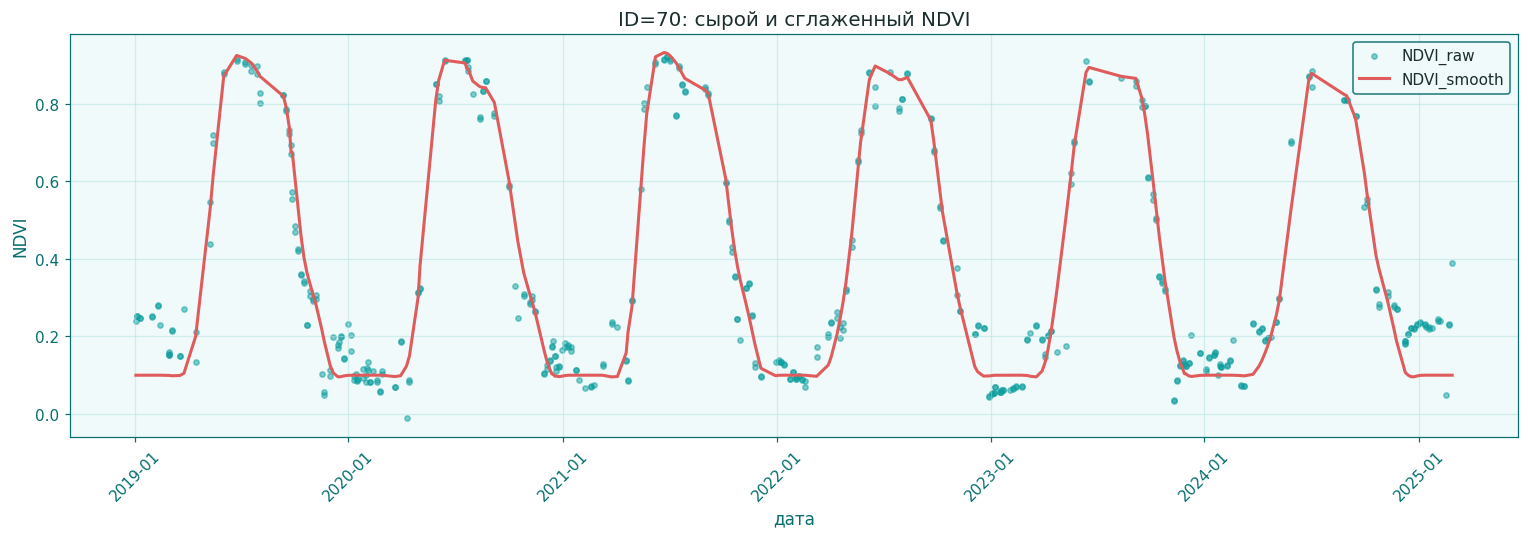

In [8]:
example_id = all_ids[0]
subset = ndvi_all[ndvi_all["ID"] == example_id].sort_values("datetime_utc")

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    subset["datetime_utc"],
    subset["NDVI_raw"],
    s=12,
    alpha=0.5,
    color=TEAL,
    label="NDVI_raw",
)
ax.plot(
    subset["datetime_utc"],
    subset["NDVI_smooth"],
    color=ACCENT,
    linewidth=2,
    label="NDVI_smooth",
)
ax.set_title(f"ID={example_id}: сырой и сглаженный NDVI")
ax.set_xlabel("дата")
ax.set_ylabel("NDVI")
ax.legend(loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Часть 3. Построение погодных признаков

Модуль weather_features.py содержит 4 независимые функции для построения погодных 
признаков. Ключевая особенность: Landsat делает снимки с промежутками в несколько 
дней, тогда как ERA5 содержит данные за каждый час. Поэтому нельзя просто 
слить датасеты — функции фич работают с непрерывными часовыми рядами ERA5 и 
самостоятельно вычисляют агрегаты за нужные временные окна.

### Обзор функций модуля weather_features.py

| # | Функция | Описание | Входные данные |
|---|---|---|---|
| 1 | add_weather_features_1 | Значения в ближайший час к снимку | era5_hourly (почасовые) + snapshots |
| 2 | add_weather_features_2 | min/max/mean за 1,2,5,7,10,14 дней | era5_hourly (почасовые) + snapshots |
| 3 | add_weather_features_3 | min/max/mean за лаги 2,3,4,5 дней | era5_hourly (почасовые) + snapshots |
| 4 | add_weather_features_4 | Дневные/ночные агрегаты (10-16, 22-04 local) | era5_hourly (почасовые) + snapshots |

### Критически важный вывод по подготовке данных

Все 4 функции из weather_features.py работают с **почасовыми** данными ERA5, 
НЕ с дневными. Внутри каждой функции вызывается prepare_era5(), которая:
- Парсит datetime_str_utc в UTC
- Вычисляет UTC-смещение по долготе: offset = round(lon / 15)
- Определяет local_hour для каждого часа
- Создаёт маски is_daytime (10-16) и is_nighttime (22-04)

Агрегация по временным окнам (1-14 дней, лаги) выполняется внутри самих 
функций на уровне секунд (int64), поэтому нет необходимости предварительно 
агрегировать ERA5. Почасовые данные должны быть поданы **как есть**.

Для корректной работы в снимках (snapshots) должны присутствовать колонки:
- ID, datetime_str_utc, center_lon, center_lat


### Загрузка модуля weather_features.py (без изменений)


In [9]:
import numpy as np
import pandas as pd
import time as _time

WEATHER_COLS = [
    "temperature_2m",
    "skin_temperature",
    "total_precipitation_hourly",
    "surface_solar_radiation_downwards_hourly",
    "volumetric_soil_water_layer_1",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "total_evaporation_hourly",
    "dewpoint_temperature_2m",
    "evaporation_from_vegetation_transpiration_hourly",
]

AGG_FUNCS = ["min", "max", "mean"]
ROLLING_WINDOWS_DAYS = [1, 2, 5, 7, 10, 14]
LAG_DAYS = [2, 3, 4, 5]
SEC_PER_HOUR = 3600


def prepare_era5(era5_hourly):
    """подготовка era5: парсинг дат, сортировка, вычисление local hour и масок."""
    df = era5_hourly.copy()
    df["datetime_utc"] = pd.to_datetime(df["datetime_str_utc"], utc=True)
    df["utc_offset"] = np.round(df["center_lon"] / 15.0).astype(int)
    df["local_hour"] = (
        df["datetime_utc"] + pd.to_timedelta(df["utc_offset"], unit="h")
    ).dt.hour
    df["is_daytime"] = df["local_hour"].between(10, 15, inclusive="both")
    df["is_nighttime"] = (df["local_hour"] >= 22) | (df["local_hour"] <= 3)
    df = df.sort_values(["ID", "datetime_utc"]).reset_index(drop=True)
    return df


def prepare_snapshots(df_snapshots):
    """подготовка снимков: парсинг дат."""
    df = df_snapshots.copy()
    df["datetime_utc"] = pd.to_datetime(df["datetime_str_utc"], utc=True)
    return df


def _compute_windowed_aggs(
    era5_sorted, snap_times_i64, id_vals, window_spec, weather_cols, masks=None
):
    """
    универсальная функция для вычисления min/max/mean по временным окнам.

    параметры:
        era5_sorted: подготовленный era5 (отсортирован по ID, datetime_utc)
        snap_times_i64: ndarray[int64] — время каждого снимка в секундах (utc)
        id_vals: ndarray — ID каждого снимка
        window_spec: список кортежей (t_offset_start, t_offset_end, suffix_name)
            интервал: (t - t_offset_start, t - t_offset_end]
        weather_cols: список колонок для агрегации
        masks: dict {era5_mask_col: prefix} или None
    """
    index = {}
    for id_val, grp in era5_sorted.groupby("ID"):
        times = grp["datetime_utc"].values.astype("datetime64[s]").astype(np.int64)
        vals = {c: grp[c].values.astype(np.float64) for c in weather_cols}
        m = {}
        if masks is not None:
            for mk in masks:
                m[mk] = grp[mk].values
        index[id_val] = (times, vals, m)

    n = len(snap_times_i64)
    result = {}
    mask_iter = masks if masks is not None else {None: None}

    for mask_key, _ in mask_iter.items():
        prefix = f"{masks[mask_key]}_" if mask_key is not None else ""
        for t_off_start, t_off_end, suffix in window_spec:
            for col in weather_cols:
                for agg in AGG_FUNCS:
                    col_name = f"{col}_{prefix}{agg}_{suffix}"
                    result[col_name] = np.full(n, np.nan)

    unique_ids = np.unique(id_vals)
    for uid in unique_ids:
        if uid not in index:
            continue

        e_times, e_vals, e_masks = index[uid]
        snap_mask = id_vals == uid
        s_idx = np.where(snap_mask)[0]
        s_times = snap_times_i64[snap_mask]

        for mask_key, _ in mask_iter.items():
            prefix = f"{masks[mask_key]}_" if mask_key is not None else ""

            if mask_key is not None and mask_key in e_masks:
                base_mask = e_masks[mask_key]
            elif mask_key is not None:
                continue
            else:
                base_mask = None

            for t_off_start, t_off_end, suffix in window_spec:
                left_arr = np.searchsorted(e_times, s_times - t_off_start, side="left")
                right_arr = np.searchsorted(e_times, s_times - t_off_end, side="right")

                for col in weather_cols:
                    e_col = e_vals[col]

                    for agg in AGG_FUNCS:
                        col_name = f"{col}_{prefix}{agg}_{suffix}"
                        out = result[col_name]

                        for j in range(len(s_idx)):
                            l, r = left_arr[j], right_arr[j]
                            if l >= r:
                                continue
                            chunk = e_col[l:r]
                            if base_mask is not None:
                                chunk = chunk[base_mask[l:r]]
                                if len(chunk) == 0:
                                    continue
                            if agg == "min":
                                out[s_idx[j]] = np.nanmin(chunk)
                            elif agg == "max":
                                out[s_idx[j]] = np.nanmax(chunk)
                            elif agg == "mean":
                                out[s_idx[j]] = np.nanmean(chunk)

    return result


def add_weather_features_1(df_snapshots, era5_hourly):
    """для каждого снимка находит ближайший час в era5 и берёт значения «как есть»."""
    era5 = era5_hourly.copy()
    if "datetime_utc" not in era5.columns:
        era5 = prepare_era5(era5)

    snaps = prepare_snapshots(df_snapshots)

    lookup = {}
    for id_val, grp in era5.groupby("ID"):
        ts = grp["datetime_utc"].values.astype("datetime64[s]").astype(np.int64)
        vals = {c: grp[c].values.astype(np.float64) for c in WEATHER_COLS}
        lookup[id_val] = (ts, vals)

    snap_rounded = (
        pd.Series(snaps["datetime_utc"].values)
        .dt.round("h")
        .values.astype("datetime64[s]")
        .astype(np.int64)
    )
    snap_ids = snaps["ID"].values
    n = len(snaps)

    result_cols = {}
    for col in WEATHER_COLS:
        result_cols[f"{col}_nearest"] = np.full(n, np.nan)

    for uid in np.unique(snap_ids):
        if uid not in lookup:
            continue
        e_ts, e_vals = lookup[uid]
        mask = snap_ids == uid
        idx = np.where(mask)[0]
        queries = snap_rounded[idx]

        pos = np.searchsorted(e_ts, queries, side="left")

        for k in range(len(idx)):
            best = None
            best_dist = np.inf
            for cand in [pos[k] - 1, pos[k]]:
                if 0 <= cand < len(e_ts):
                    d = abs(int(e_ts[cand]) - int(queries[k]))
                    if d < best_dist:
                        best_dist = d
                        best = cand
            if best is not None and best_dist <= 1800:
                for col in WEATHER_COLS:
                    result_cols[f"{col}_nearest"][idx[k]] = e_vals[col][best]

    new_df = pd.DataFrame(result_cols, index=df_snapshots.index)
    return pd.concat([df_snapshots, new_df], axis=1)


def add_weather_features_2(df_snapshots, era5_hourly):
    """min/max/mean за 1, 2, 5, 7, 10, 14 дней от часа снимка."""
    era5 = era5_hourly.copy()
    if "datetime_utc" not in era5.columns:
        era5 = prepare_era5(era5)

    snaps = prepare_snapshots(df_snapshots)
    snap_ts = snaps["datetime_utc"].values.astype("datetime64[s]").astype(np.int64)
    snap_ids = snaps["ID"].values

    window_spec = [
        (d * 24 * SEC_PER_HOUR, 0, f"last_{d}d") for d in ROLLING_WINDOWS_DAYS
    ]

    aggs = _compute_windowed_aggs(era5, snap_ts, snap_ids, window_spec, WEATHER_COLS)

    new_df = pd.DataFrame(aggs, index=df_snapshots.index)
    return pd.concat([df_snapshots, new_df], axis=1)


def add_weather_features_3(df_snapshots, era5_hourly):
    """min/max/mean за лаги 2, 3, 4, 5 дней назад от часа снимка."""
    era5 = era5_hourly.copy()
    if "datetime_utc" not in era5.columns:
        era5 = prepare_era5(era5)

    snaps = prepare_snapshots(df_snapshots)
    snap_ts = snaps["datetime_utc"].values.astype("datetime64[s]").astype(np.int64)
    snap_ids = snaps["ID"].values

    window_spec = [
        (lag * 24 * SEC_PER_HOUR, (lag - 1) * 24 * SEC_PER_HOUR, f"lag{lag}")
        for lag in LAG_DAYS
    ]

    aggs = _compute_windowed_aggs(era5, snap_ts, snap_ids, window_spec, WEATHER_COLS)

    new_df = pd.DataFrame(aggs, index=df_snapshots.index)
    return pd.concat([df_snapshots, new_df], axis=1)


def add_weather_features_4(df_snapshots, era5_hourly):
    """дневные (10-16 local) и ночные (22-04 local) min/max/mean."""
    era5 = era5_hourly.copy()
    if "datetime_utc" not in era5.columns:
        era5 = prepare_era5(era5)

    snaps = prepare_snapshots(df_snapshots)
    snap_ts = snaps["datetime_utc"].values.astype("datetime64[s]").astype(np.int64)
    snap_ids = snaps["ID"].values

    rolling_spec = [
        (d * 24 * SEC_PER_HOUR, 0, f"last_{d}d") for d in ROLLING_WINDOWS_DAYS
    ]
    lag_spec = [
        (lag * 24 * SEC_PER_HOUR, (lag - 1) * 24 * SEC_PER_HOUR, f"lag{lag}")
        for lag in LAG_DAYS
    ]
    window_spec = rolling_spec + lag_spec

    masks = {"is_daytime": "day", "is_nighttime": "night"}

    aggs = _compute_windowed_aggs(
        era5, snap_ts, snap_ids, window_spec, WEATHER_COLS, masks
    )

    new_df = pd.DataFrame(aggs, index=df_snapshots.index)
    return pd.concat([df_snapshots, new_df], axis=1)


def add_all_weather_features(df_snapshots, era5_hourly):
    """применяет все 4 функции последовательно."""
    era5 = prepare_era5(era5_hourly)
    print("  era5 подготовлен")

    t0 = _time.time()
    df = add_weather_features_1(df_snapshots, era5)
    print(
        f"  ф-ция 1 (nearest hour):  +{df.shape[1] - df_snapshots.shape[1]} колонок, {_time.time()-t0:.1f}с"
    )

    t0 = _time.time()
    n1 = df.shape[1]
    df = add_weather_features_2(df, era5)
    print(
        f"  ф-ция 2 (rolling):      +{df.shape[1]-n1} колонок, {_time.time()-t0:.1f}с"
    )

    t0 = _time.time()
    n2 = df.shape[1]
    df = add_weather_features_3(df, era5)
    print(
        f"  ф-ция 3 (lags):         +{df.shape[1]-n2} колонок, {_time.time()-t0:.1f}с"
    )

    t0 = _time.time()
    n3 = df.shape[1]
    df = add_weather_features_4(df, era5)
    print(
        f"  ф-ция 4 (day/night):    +{df.shape[1]-n3} колонок, {_time.time()-t0:.1f}с"
    )

    return df


print("модуль weather_features.py загружен")

модуль weather_features.py загружен


### Подготовка снимков и данных ERA5 для построения признаков

Подготовим два датасета:
- snap_base — снимки Landsat с координатами и шумом (для присоединения фичей)
- era5_hourly — почасовые данные ERA5 (вход для функций модуля)


In [10]:
landsat_coords = pd.read_csv("landsat_data_2019_2025.csv")
coord_lookup = (
    landsat_coords.groupby("ID")[["center_lon", "center_lat"]].first().reset_index()
)

snap_base = ndvi_all[["ID", "datetime_utc", "NDVI_raw", "NDVI_smooth", "noise"]].copy()
snap_base["datetime_str_utc"] = snap_base["datetime_utc"].dt.strftime(
    "%Y-%m-%d %H:%M:%S"
)
snap_base = snap_base.merge(coord_lookup, on="ID", how="left")
print(f"snap_base: {snap_base.shape}")
print(f"пропуски в noise: {snap_base['noise'].isna().sum()}")

era5_hourly = pd.read_csv(ERA5_HOURLY_PATH)
print(f"era5_hourly: {era5_hourly.shape}")

# Подготавливаем ERA5 один раз (все функции вызывают prepare_era5 внутри,
# но мы вызовем её здесь для ускорения, т.к. функции проверяют наличие datetime_utc)
era5_prepared = prepare_era5(era5_hourly)
print(f"era5_prepared: {era5_prepared.shape}")
print(f"колонки era5_prepared: {list(era5_prepared.columns)}")
snap_base.head(3)

snap_base: (7782, 8)
пропуски в noise: 9
era5_hourly: (810720, 15)
era5_prepared: (810720, 20)
колонки era5_prepared: ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'temperature_2m', 'skin_temperature', 'total_precipitation_hourly', 'surface_solar_radiation_downwards_hourly', 'volumetric_soil_water_layer_1', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'total_evaporation_hourly', 'dewpoint_temperature_2m', 'evaporation_from_vegetation_transpiration_hourly', 'datetime_utc', 'utc_offset', 'local_hour', 'is_daytime', 'is_nighttime']


,ID,datetime_utc,NDVI_raw,NDVI_smooth,noise,datetime_str_utc,center_lon,center_lat
0,70,2019-01-03 02:24:00,0.238911,0.09999,0.138922,2019-01-03 02:24:00,131.518922,44.262327
1,70,2019-01-05 02:15:00,0.253047,0.09999,0.153058,2019-01-05 02:15:00,131.518922,44.262327
2,70,2019-01-05 02:15:00,0.252309,0.09999,0.152319,2019-01-05 02:15:00,131.518922,44.262327


### Функция 1: add_weather_features_1 — ближайший час к снимку

**Описание:** Для каждого снимка находит ближайший час в ERA5 и берёт значения 
«как есть». Максимальное отклонение — 30 минут (1800 секунд).

**Анализ входных данных:**
- Требует **почасовые** данные ERA5 (prepare_era5 добавляет datetime_utc, local_hour)
- Требует снимки с колонками ID, datetime_str_utc, center_lon, center_lat
- Использует только WEATHER_COLS (10 переменных)
- Генерирует 10 новых колонок (по одной на переменную с суффиксом _nearest)

**Вывод:** Подаём snap_base и era5_prepared (почасовые) без дополнительной подготовки.


In [11]:
print("=== Функция 1: ближайший час ===")
t0 = time.time()
features_1 = add_weather_features_1(snap_base.copy(), era5_prepared)
elapsed = time.time() - t0

new_cols_1 = [c for c in features_1.columns if c.endswith("_nearest")]
print(f"время: {elapsed:.1f}с")
print(f"новых колонок: {len(new_cols_1)}")
print(f"пропуски в новых колонках:")
for c in new_cols_1:
    n_na = features_1[c].isna().sum()
    print(f"  {c}: {n_na} ({100*n_na/len(features_1):.1f}%)")
print(f"\nfeatures_1: {features_1.shape}")
features_1[new_cols_1].describe()

=== Функция 1: ближайший час ===
время: 0.4с
новых колонок: 10
пропуски в новых колонках:
  temperature_2m_nearest: 0 (0.0%)
  skin_temperature_nearest: 0 (0.0%)
  total_precipitation_hourly_nearest: 0 (0.0%)
  surface_solar_radiation_downwards_hourly_nearest: 0 (0.0%)
  volumetric_soil_water_layer_1_nearest: 0 (0.0%)
  u_component_of_wind_10m_nearest: 0 (0.0%)
  v_component_of_wind_10m_nearest: 0 (0.0%)
  total_evaporation_hourly_nearest: 0 (0.0%)
  dewpoint_temperature_2m_nearest: 0 (0.0%)
  evaporation_from_vegetation_transpiration_hourly_nearest: 0 (0.0%)

features_1: (7782, 18)


,temperature_2m_nearest,skin_temperature_nearest,total_precipitation_hourly_nearest,surface_solar_radiation_downwards_hourly_nearest,volumetric_soil_water_layer_1_nearest,u_component_of_wind_10m_nearest,v_component_of_wind_10m_nearest,total_evaporation_hourly_nearest,dewpoint_temperature_2m_nearest,evaporation_from_vegetation_transpiration_hourly_nearest
count,7782.000000,7782.000000,7.782000e+03,7.782000e+03,7782.000000,7782.000000,7782.000000,7782.000000,7782.000000,7.782000e+03
mean,277.229123,278.669623,7.334363e-06,1.969594e+06,0.359962,1.286942,-0.585648,-0.000147,267.230199,-4.872437e-07
std,13.867083,13.860341,4.840853e-05,6.430246e+05,0.033647,1.287398,1.936342,0.000155,13.782775,3.006304e-06
min,246.568802,247.892654,-3.725290e-09,2.932955e+05,0.126526,-3.586853,-7.838303,-0.000608,237.799072,-7.515243e-05
25%,264.405197,265.750660,0.000000e+00,1.350252e+06,0.339279,0.386536,-2.027448,-0.000253,255.725060,-1.164153e-10
50%,277.832932,279.348602,0.000000e+00,1.941172e+06,0.364380,1.198936,-0.543375,-0.000078,265.701660,0.000000e+00
75%,289.448257,291.022758,5.215406e-08,2.542529e+06,0.381165,2.126343,0.848292,-0.000020,278.460526,0.000000e+00
max,305.086685,309.491653,2.582995e-03,3.223424e+06,0.438995,7.409363,5.863631,0.000012,297.680969,1.932320e-06


### Обучение моделей на признаках


In [12]:
def train_and_evaluate(df, feature_cols, target_col="noise", label=""):
    """Универсальная функция обучения и оценки Ridge + DecisionTree."""
    df_clean = df.dropna(subset=feature_cols + [target_col])
    X = df_clean[feature_cols].values
    y = df_clean[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Imputer + Scaler
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train)
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_imp = imputer.transform(X_test)
    X_test_sc = scaler.transform(X_test_imp)

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_sc, y_train)
    y_pred_ridge = ridge.predict(X_test_sc)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

    # DecisionTree
    tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree.fit(X_train_imp, y_train)  # tree не требует масштабирования
    y_pred_tree = tree.predict(X_test_imp)
    r2_tree = r2_score(y_test, y_pred_tree)
    mae_tree = mean_absolute_error(y_test, y_pred_tree)
    rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

    results = {
        "label": label,
        "n_features": len(feature_cols),
        "n_samples_train": len(y_train),
        "n_samples_test": len(y_test),
        "ridge_r2": r2_ridge,
        "ridge_mae": mae_ridge,
        "ridge_rmse": rmse_ridge,
        "tree_r2": r2_tree,
        "tree_mae": mae_tree,
        "tree_rmse": rmse_tree,
        "y_test": y_test,
        "y_pred_ridge": y_pred_ridge,
        "y_pred_tree": y_pred_tree,
        "ridge_model": ridge,
        "tree_model": tree,
        "feature_cols": feature_cols,
    }
    return results


print("вспомогательная функция train_and_evaluate определена")

вспомогательная функция train_and_evaluate определена


In [13]:
results_1 = train_and_evaluate(features_1, new_cols_1, label="Функция 1 (nearest hour)")

print(f"=== Результаты: {results_1['label']} ===")
print(
    f"Признаков: {results_1['n_features']}, Train: {results_1['n_samples_train']}, Test: {results_1['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_1['ridge_r2']:.4f}, MAE={results_1['ridge_mae']:.4f}, RMSE={results_1['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_1['tree_r2']:.4f}, MAE={results_1['tree_mae']:.4f}, RMSE={results_1['tree_rmse']:.4f}"
)

=== Результаты: Функция 1 (nearest hour) ===
Признаков: 10, Train: 6218, Test: 1555

Ridge:       R2=0.1896, MAE=0.0841, RMSE=0.1110
DecisionTree: R2=0.2803, MAE=0.0757, RMSE=0.1046


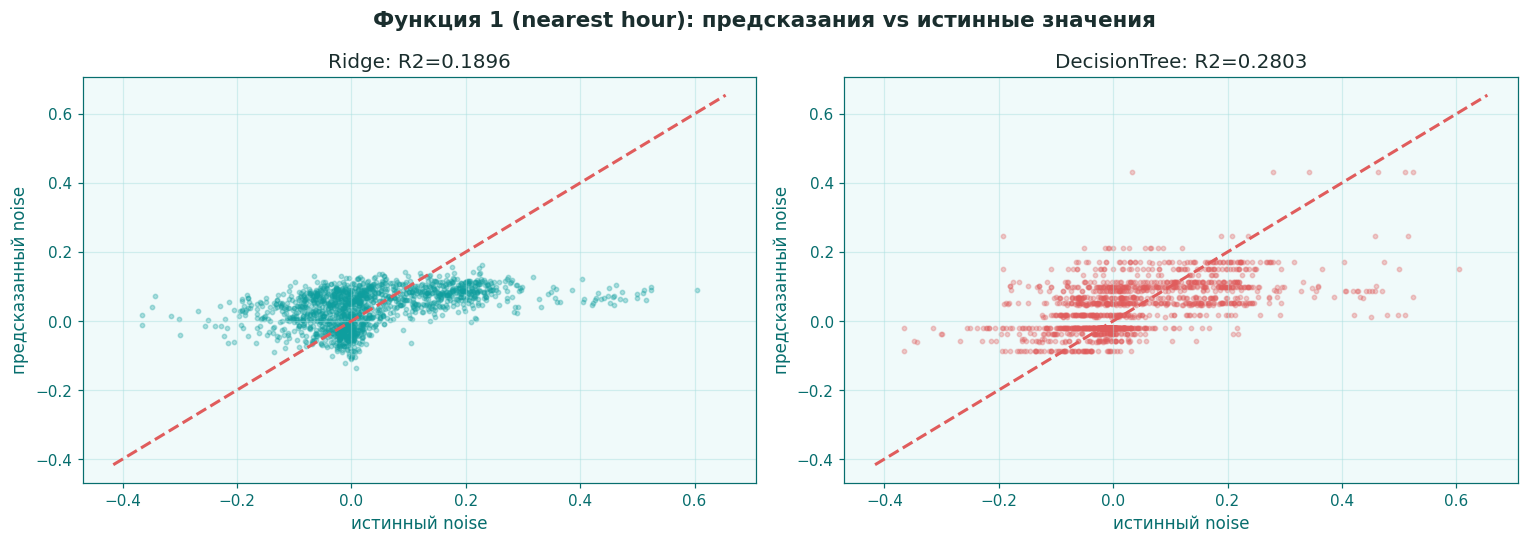

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_1["y_test"], results_1["y_pred_ridge"], alpha=0.3, s=8, color=COLORS_4[0]
)
lims = [results_1["y_test"].min() - 0.05, results_1["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge: R2={results_1['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_1["y_test"], results_1["y_pred_tree"], alpha=0.3, s=8, color=COLORS_4[1]
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree: R2={results_1['tree_r2']:.4f}")

plt.suptitle(
    f"{results_1['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Функция 2: add_weather_features_2 — rolling агрегаты за 1,2,5,7,10,14 дней

**Описание:** Вычисляет min/max/mean для каждой погодной переменной за последние 
1, 2, 5, 7, 10, 14 дней от часа съёмки. Интервал: (snapshot_time - N*24h, snapshot_time].

**Анализ входных данных:**
- Требует **почасовые** данные ERA5 — функция сама ищет нужное количество часов 
  внутри окна N*24 часов
- Окна отсчитываются от часа съёмки, а не от 0:00
- 10 переменных x 3 агрегата x 6 окон = **180 новых колонок**

**Вывод:** Подаём snap_base и era5_prepared (почасовые).


In [15]:
print("=== Функция 2: rolling агрегаты ===")
t0 = time.time()
features_2 = add_weather_features_2(snap_base.copy(), era5_prepared)
elapsed = time.time() - t0

new_cols_2 = [
    c
    for c in features_2.columns
    if c not in snap_base.columns and not c.endswith("_nearest")
]
print(f"время: {elapsed:.1f}с")
print(f"новых колонок: {len(new_cols_2)}")
na_pct = features_2[new_cols_2].isna().mean().sort_values(ascending=False)
print(f"топ-5 по пропускам:")
for c in na_pct.head(5).index:
    print(f"  {c}: {na_pct[c]*100:.1f}%")
print(f"\nfeatures_2: {features_2.shape}")

=== Функция 2: rolling агрегаты ===
время: 19.8с
новых колонок: 180
топ-5 по пропускам:
  temperature_2m_min_last_1d: 0.0%
  temperature_2m_max_last_1d: 0.0%
  temperature_2m_mean_last_1d: 0.0%
  skin_temperature_min_last_1d: 0.0%
  skin_temperature_max_last_1d: 0.0%

features_2: (7782, 188)


In [16]:
results_2 = train_and_evaluate(
    features_2, new_cols_2, label="Функция 2 (rolling 1-14d)"
)

print(f"=== Результаты: {results_2['label']} ===")
print(
    f"Признаков: {results_2['n_features']}, Train: {results_2['n_samples_train']}, Test: {results_2['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_2['ridge_r2']:.4f}, MAE={results_2['ridge_mae']:.4f}, RMSE={results_2['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_2['tree_r2']:.4f}, MAE={results_2['tree_mae']:.4f}, RMSE={results_2['tree_rmse']:.4f}"
)

=== Результаты: Функция 2 (rolling 1-14d) ===
Признаков: 180, Train: 6218, Test: 1555

Ridge:       R2=0.3145, MAE=0.0750, RMSE=0.1021
DecisionTree: R2=0.4047, MAE=0.0676, RMSE=0.0952


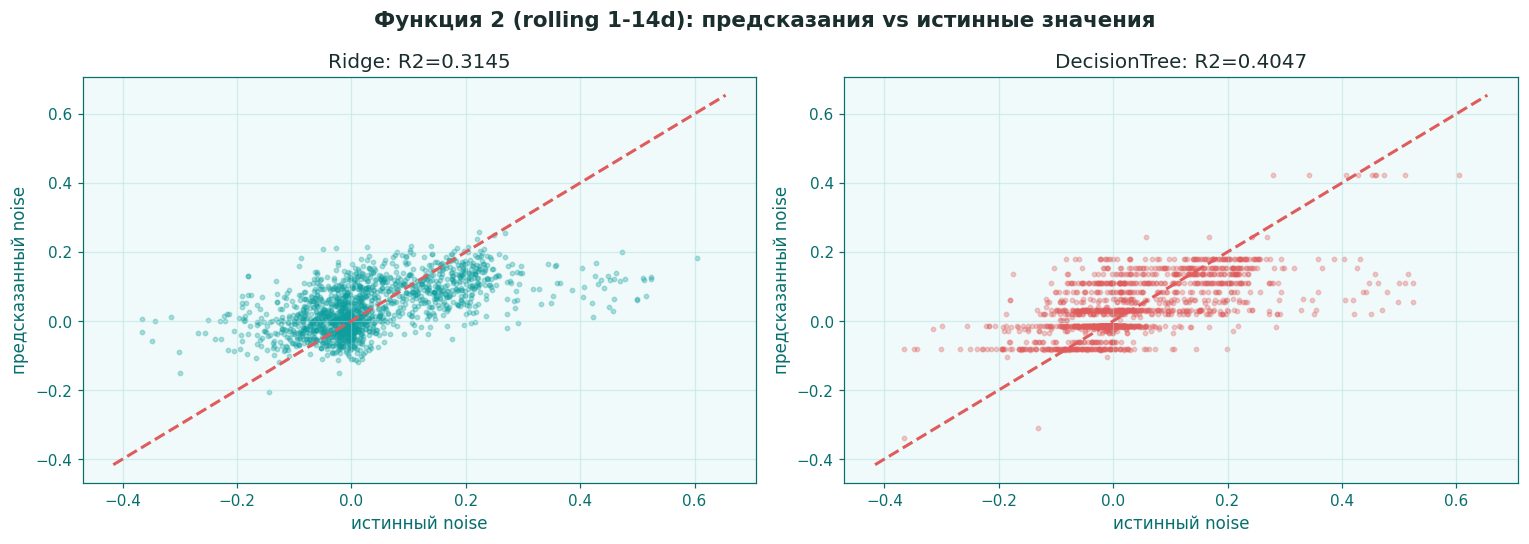

Топ-10 признаков по важности (DecisionTree):
temperature_2m_mean_last_14d                                    0.502102
evaporation_from_vegetation_transpiration_hourly_min_last_5d    0.113895
total_precipitation_hourly_mean_last_10d                        0.078703
surface_solar_radiation_downwards_hourly_max_last_7d            0.045401
u_component_of_wind_10m_min_last_14d                            0.042117
v_component_of_wind_10m_min_last_1d                             0.031696
total_evaporation_hourly_mean_last_7d                           0.029407
temperature_2m_min_last_14d                                     0.025216
skin_temperature_mean_last_10d                                  0.023199
surface_solar_radiation_downwards_hourly_max_last_14d           0.013484
dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_2["y_test"], results_2["y_pred_ridge"], alpha=0.3, s=8, color=COLORS_4[0]
)
lims = [results_2["y_test"].min() - 0.05, results_2["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge: R2={results_2['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_2["y_test"], results_2["y_pred_tree"], alpha=0.3, s=8, color=COLORS_4[1]
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree: R2={results_2['tree_r2']:.4f}")

plt.suptitle(
    f"{results_2['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Feature importances
importances_2 = pd.Series(
    results_2["tree_model"].feature_importances_, index=new_cols_2
).sort_values(ascending=False)
print("Топ-10 признаков по важности (DecisionTree):")
print(importances_2.head(10))

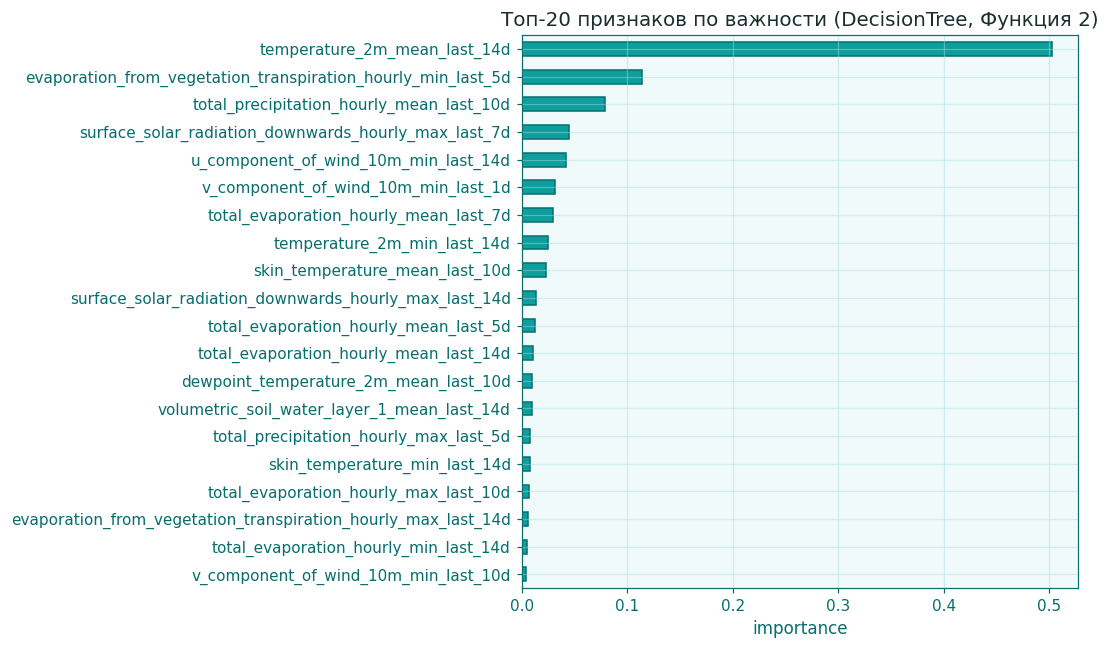

In [18]:
top_20_imp2 = importances_2.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_20_imp2.sort_values().plot(kind="barh", ax=ax, color=TEAL, edgecolor=TEAL_DARK)
ax.set_title("Топ-20 признаков по важности (DecisionTree, Функция 2)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

### Функция 3: add_weather_features_3 — лаги 2, 3, 4, 5 дней

**Описание:** Вычисляет min/max/mean за конкретные сутки назад от часа съёмки. 
Лаг 2 = интервал (-48h, -24h], лаг 3 = (-72h, -48h], и т.д. Лаг 1 отсутствует, 
т.к. совпадает с окном last_1d из функции 2.

**Анализ входных данных:**
- Требует **почасовые** данные ERA5
- 10 переменных x 3 агрегата x 4 лага = **120 новых колонок**
- Эти признаки описывают погодные условия конкретных суток перед съёмкой

**Вывод:** Подаём snap_base и era5_prepared (почасовые).


In [19]:
print("=== Функция 3: лаги 2-5 дней ===")
t0 = time.time()
features_3 = add_weather_features_3(snap_base.copy(), era5_prepared)
elapsed = time.time() - t0

new_cols_3 = [
    c
    for c in features_3.columns
    if c not in snap_base.columns and c not in new_cols_1 and c not in new_cols_2
]
print(f"время: {elapsed:.1f}с")
print(f"новых колонок: {len(new_cols_3)}")
na_pct3 = features_3[new_cols_3].isna().mean().sort_values(ascending=False)
print(f"топ-5 по пропускам:")
for c in na_pct3.head(5).index:
    print(f"  {c}: {na_pct3[c]*100:.1f}%")
print(f"\nfeatures_3: {features_3.shape}")

=== Функция 3: лаги 2-5 дней ===
время: 12.9с
новых колонок: 120
топ-5 по пропускам:
  surface_solar_radiation_downwards_hourly_max_lag5: 0.3%
  surface_solar_radiation_downwards_hourly_mean_lag5: 0.3%
  total_precipitation_hourly_mean_lag5: 0.3%
  surface_solar_radiation_downwards_hourly_min_lag5: 0.3%
  volumetric_soil_water_layer_1_min_lag5: 0.3%

features_3: (7782, 128)


In [20]:
results_3 = train_and_evaluate(features_3, new_cols_3, label="Функция 3 (lags 2-5d)")

print(f"=== Результаты: {results_3['label']} ===")
print(
    f"Признаков: {results_3['n_features']}, Train: {results_3['n_samples_train']}, Test: {results_3['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_3['ridge_r2']:.4f}, MAE={results_3['ridge_mae']:.4f}, RMSE={results_3['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_3['tree_r2']:.4f}, MAE={results_3['tree_mae']:.4f}, RMSE={results_3['tree_rmse']:.4f}"
)

=== Результаты: Функция 3 (lags 2-5d) ===
Признаков: 120, Train: 6200, Test: 1551

Ridge:       R2=0.2514, MAE=0.0756, RMSE=0.1024
DecisionTree: R2=0.3379, MAE=0.0692, RMSE=0.0963


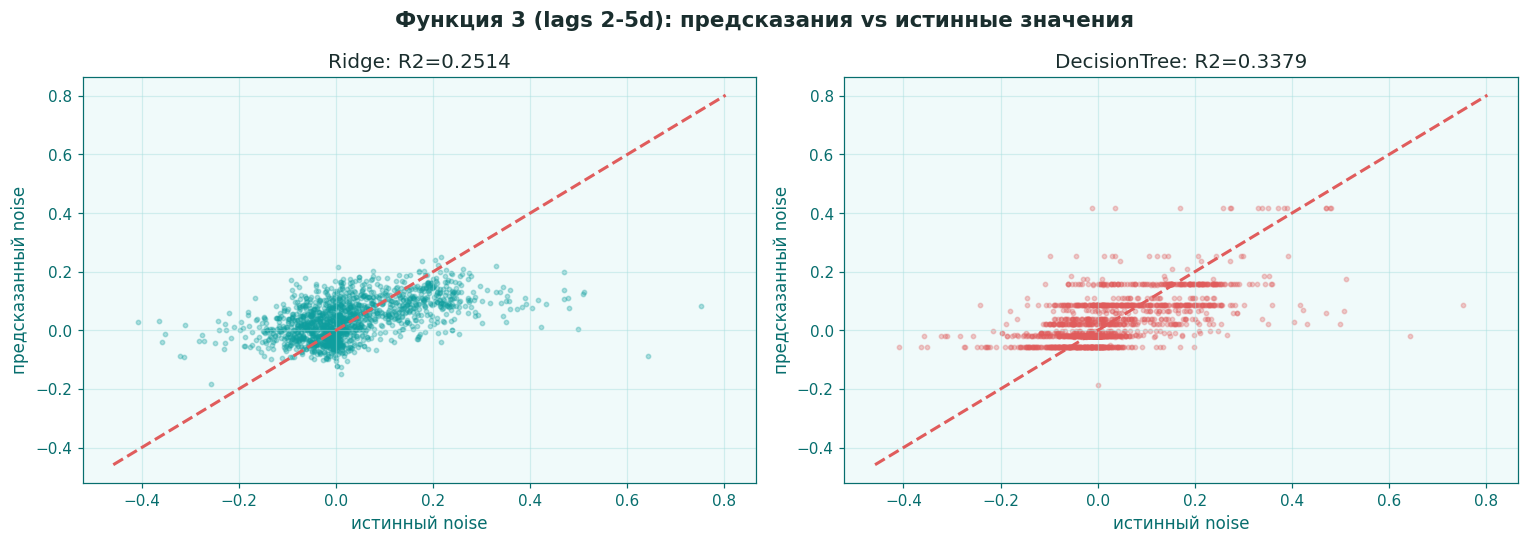

Топ-10 признаков по важности (DecisionTree):
temperature_2m_min_lag4                                       0.451931
evaporation_from_vegetation_transpiration_hourly_min_lag4     0.142987
v_component_of_wind_10m_max_lag5                              0.061868
total_evaporation_hourly_mean_lag2                            0.054654
evaporation_from_vegetation_transpiration_hourly_mean_lag3    0.040374
total_evaporation_hourly_mean_lag5                            0.033971
skin_temperature_min_lag2                                     0.025300
temperature_2m_min_lag3                                       0.024116
u_component_of_wind_10m_min_lag5                              0.016751
volumetric_soil_water_layer_1_min_lag2                        0.016596
dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_3["y_test"], results_3["y_pred_ridge"], alpha=0.3, s=8, color=COLORS_4[0]
)
lims = [results_3["y_test"].min() - 0.05, results_3["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge: R2={results_3['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_3["y_test"], results_3["y_pred_tree"], alpha=0.3, s=8, color=COLORS_4[1]
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree: R2={results_3['tree_r2']:.4f}")

plt.suptitle(
    f"{results_3['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

importances_3 = pd.Series(
    results_3["tree_model"].feature_importances_, index=new_cols_3
).sort_values(ascending=False)
print("Топ-10 признаков по важности (DecisionTree):")
print(importances_3.head(10))

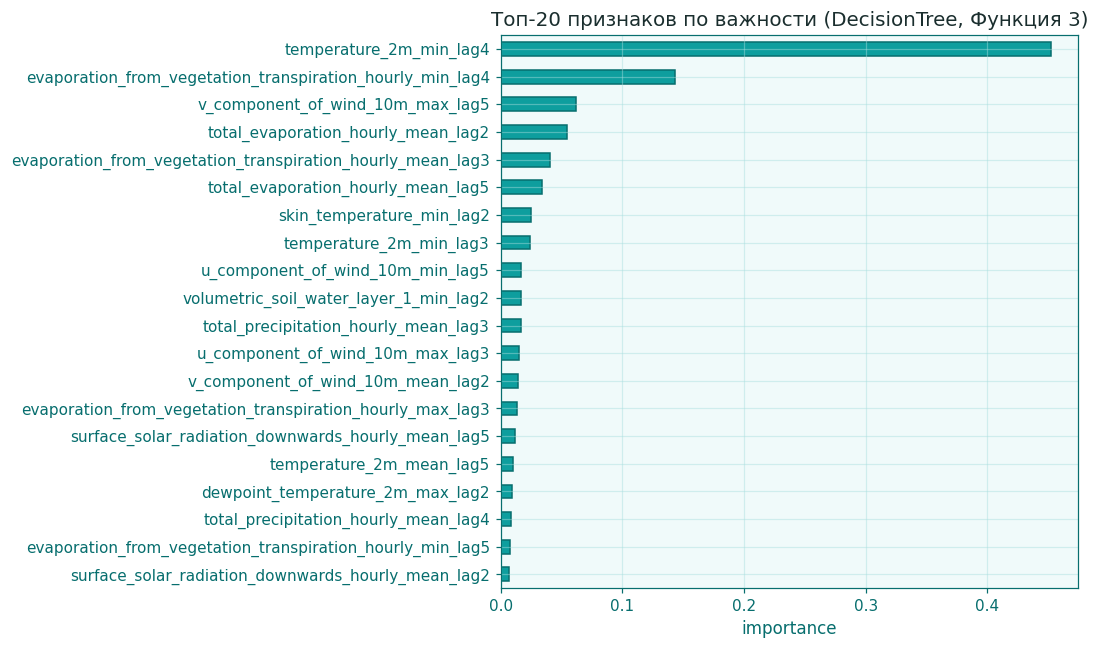

In [22]:
top_20_imp3 = importances_3.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_20_imp3.sort_values().plot(kind="barh", ax=ax, color=TEAL, edgecolor=TEAL_DARK)
ax.set_title("Топ-20 признаков по важности (DecisionTree, Функция 3)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

### Функция 4: add_weather_features_4 — дневные и ночные агрегаты

**Описание:** Вычисляет min/max/mean отдельно для дневных (10:00-16:00 local) 
и ночных (22:00-04:00 local) часов. Окна — те же, что в функциях 2 и 3: 
rolling 1-14 дней + лаги 2-5 дней. Это самая объёмная группа признаков.

**Анализ входных данных:**
- Требует **почасовые** данные ERA5 с вычисленными local_hour, is_daytime, is_nighttime 
  (prepare_era5 делает это автоматически)
- 10 переменных x 3 агрегата x (6 rolling + 4 lag) x 2 (day/night) = **600 новых колонок**
- Эти признаки разделяют влияние дневной и ночной погоды на NDVI

**Вывод:** Подаём snap_base и era5_prepared (почасовые). Ожидается наибольшее время 
вычисления из-за объёма.


In [23]:
print("=== Функция 4: дневные и ночные агрегаты ===")
t0 = time.time()
features_4 = add_weather_features_4(snap_base.copy(), era5_prepared)
elapsed = time.time() - t0

all_prev_cols = (
    set(snap_base.columns) | set(new_cols_1) | set(new_cols_2) | set(new_cols_3)
)
new_cols_4 = [c for c in features_4.columns if c not in all_prev_cols]
print(f"время: {elapsed:.1f}с")
print(f"новых колонок: {len(new_cols_4)}")
na_pct4 = features_4[new_cols_4].isna().mean().sort_values(ascending=False)
print(f"топ-5 по пропускам:")
for c in na_pct4.head(5).index:
    print(f"  {c}: {na_pct4[c]*100:.1f}%")
print(f"\nfeatures_4: {features_4.shape}")

=== Функция 4: дневные и ночные агрегаты ===
время: 74.7с
новых колонок: 600
топ-5 по пропускам:
  volumetric_soil_water_layer_1_night_mean_lag5: 0.4%
  volumetric_soil_water_layer_1_night_max_lag5: 0.4%
  total_evaporation_hourly_night_min_lag5: 0.4%
  evaporation_from_vegetation_transpiration_hourly_night_mean_lag5: 0.4%
  v_component_of_wind_10m_night_mean_lag5: 0.4%

features_4: (7782, 608)


In [24]:
results_4 = train_and_evaluate(features_4, new_cols_4, label="Функция 4 (day/night)")

print(f"=== Результаты: {results_4['label']} ===")
print(
    f"Признаков: {results_4['n_features']}, Train: {results_4['n_samples_train']}, Test: {results_4['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_4['ridge_r2']:.4f}, MAE={results_4['ridge_mae']:.4f}, RMSE={results_4['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_4['tree_r2']:.4f}, MAE={results_4['tree_mae']:.4f}, RMSE={results_4['tree_rmse']:.4f}"
)

=== Результаты: Функция 4 (day/night) ===
Признаков: 600, Train: 6191, Test: 1548

Ridge:       R2=0.3090, MAE=0.0715, RMSE=0.0987
DecisionTree: R2=0.2915, MAE=0.0690, RMSE=0.0999


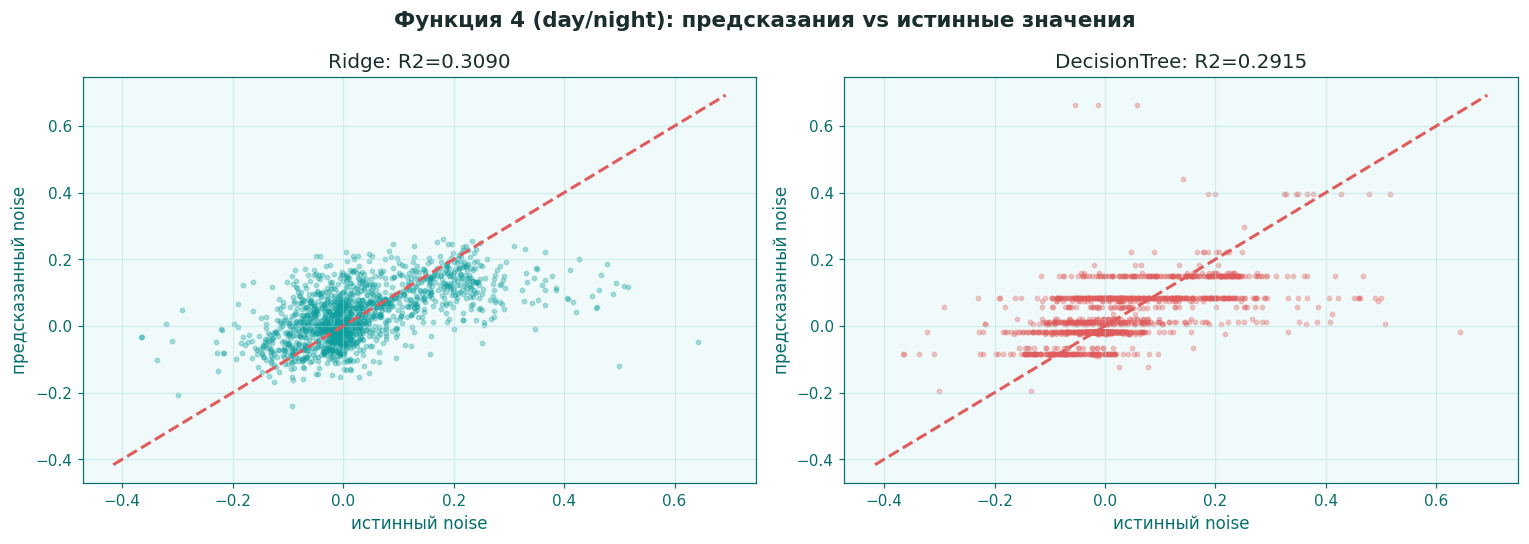

Топ-10 признаков по важности (DecisionTree):
temperature_2m_night_mean_last_14d                                    0.518384
v_component_of_wind_10m_night_max_last_14d                            0.088308
evaporation_from_vegetation_transpiration_hourly_day_min_last_14d     0.084164
total_precipitation_hourly_night_mean_last_10d                        0.045883
total_evaporation_hourly_day_mean_last_14d                            0.044406
volumetric_soil_water_layer_1_night_min_last_10d                      0.039896
evaporation_from_vegetation_transpiration_hourly_night_min_last_2d    0.038589
total_evaporation_hourly_night_min_last_10d                           0.023561
total_precipitation_hourly_day_mean_lag3                              0.020395
volumetric_soil_water_layer_1_day_mean_last_10d                       0.015461
dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_4["y_test"], results_4["y_pred_ridge"], alpha=0.3, s=8, color=COLORS_4[0]
)
lims = [results_4["y_test"].min() - 0.05, results_4["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge: R2={results_4['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_4["y_test"], results_4["y_pred_tree"], alpha=0.3, s=8, color=COLORS_4[1]
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree: R2={results_4['tree_r2']:.4f}")

plt.suptitle(
    f"{results_4['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

importances_4 = pd.Series(
    results_4["tree_model"].feature_importances_, index=new_cols_4
).sort_values(ascending=False)
print("Топ-10 признаков по важности (DecisionTree):")
print(importances_4.head(10))

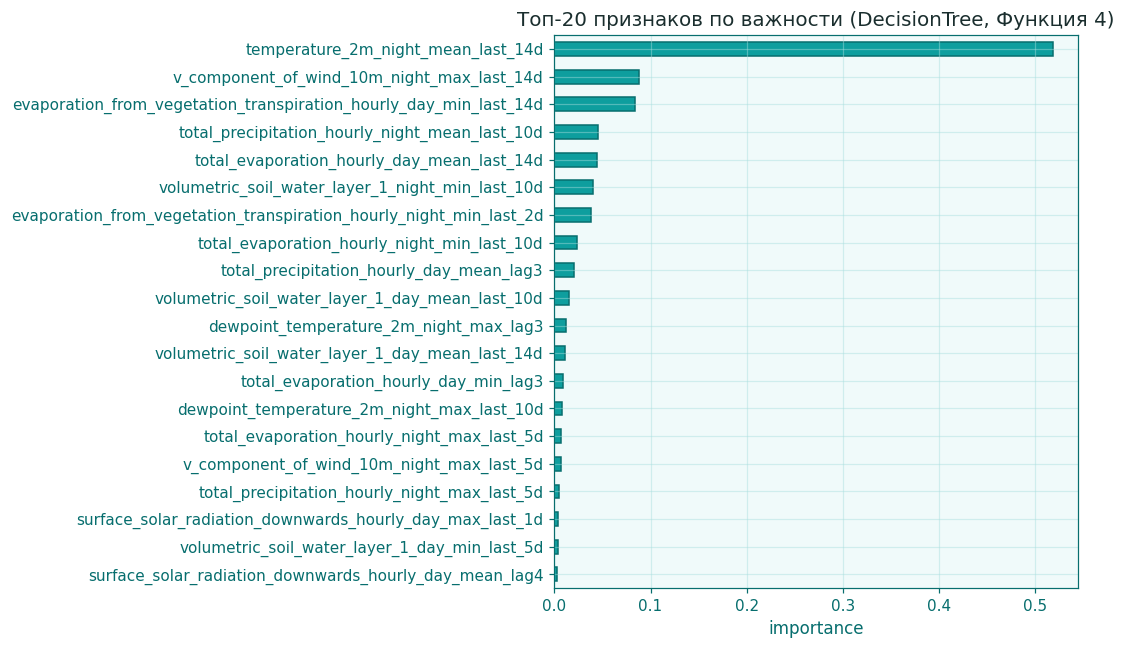

In [26]:
top_20_imp4 = importances_4.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_20_imp4.sort_values().plot(kind="barh", ax=ax, color=TEAL, edgecolor=TEAL_DARK)
ax.set_title("Топ-20 признаков по важности (DecisionTree, Функция 4)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

## Часть 4. Сравнительный анализ всех моделей

Сравним результаты всех 8 моделей (4 набора признаков x 2 модели) по метрикам 
R2, MAE и RMSE на тестовой выборке.


In [27]:
all_results = [results_1, results_2, results_3, results_4]

comparison = pd.DataFrame(
    [
        {
            "Признаки": r["label"],
            "Кол-во фичей": r["n_features"],
            "Train размер": r["n_samples_train"],
            "Test размер": r["n_samples_test"],
            "Ridge R2": r["ridge_r2"],
            "Ridge MAE": r["ridge_mae"],
            "Ridge RMSE": r["ridge_rmse"],
            "Tree R2": r["tree_r2"],
            "Tree MAE": r["tree_mae"],
            "Tree RMSE": r["tree_rmse"],
        }
        for r in all_results
    ]
)

print("=" * 100)
print(comparison.to_string(index=False))
print("=" * 100)

# Лучшая модель
best_ridge_idx = comparison["Ridge R2"].idxmax()
best_tree_idx = comparison["Tree R2"].idxmax()
print(
    f"\nЛучшая Ridge: {comparison.loc[best_ridge_idx, 'Признаки']} (R2={comparison.loc[best_ridge_idx, 'Ridge R2']:.4f})"
)
print(
    f"Лучшая DecisionTree: {comparison.loc[best_tree_idx, 'Признаки']} (R2={comparison.loc[best_tree_idx, 'Tree R2']:.4f})"
)

                 Признаки  Кол-во фичей  Train размер  Test размер  Ridge R2  Ridge MAE  Ridge RMSE  Tree R2  Tree MAE  Tree RMSE
 Функция 1 (nearest hour)            10          6218         1555  0.189577   0.084076    0.111045 0.280283  0.075660   0.104646
Функция 2 (rolling 1-14d)           180          6218         1555  0.314480   0.075048    0.102130 0.404662  0.067594   0.095175
    Функция 3 (lags 2-5d)           120          6200         1551  0.251405   0.075648    0.102444 0.337900  0.069185   0.096344
    Функция 4 (day/night)           600          6191         1548  0.308977   0.071509    0.098698 0.291527  0.068988   0.099936

Лучшая Ridge: Функция 2 (rolling 1-14d) (R2=0.3145)
Лучшая DecisionTree: Функция 2 (rolling 1-14d) (R2=0.4047)


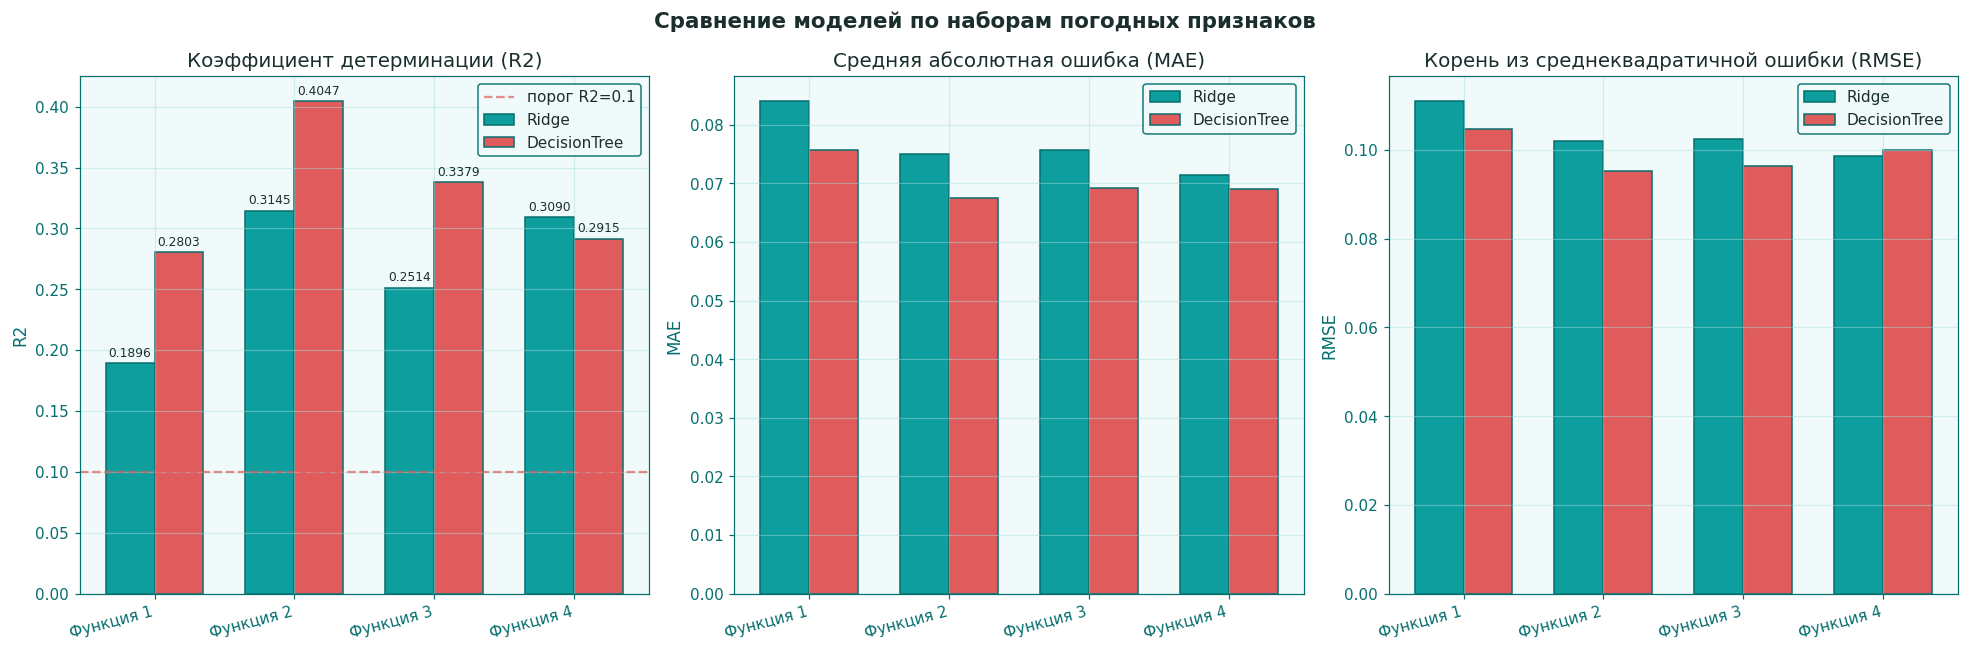

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels = [r["label"].split("(")[0].strip() for r in all_results]
x = np.arange(len(labels))
width = 0.35

# R2
ax = axes[0]
ridge_r2 = [r["ridge_r2"] for r in all_results]
tree_r2 = [r["tree_r2"] for r in all_results]
bars1 = ax.bar(
    x - width / 2,
    ridge_r2,
    width,
    label="Ridge",
    color=COLORS_4[0],
    edgecolor=TEAL_DARK,
)
bars2 = ax.bar(
    x + width / 2,
    tree_r2,
    width,
    label="DecisionTree",
    color=COLORS_4[1],
    edgecolor=TEAL_DARK,
)
ax.axhline(
    0.1, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.7, label="порог R2=0.1"
)
ax.set_ylabel("R2")
ax.set_title("Коэффициент детерминации (R2)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(loc="best")
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# MAE
ax = axes[1]
ridge_mae = [r["ridge_mae"] for r in all_results]
tree_mae = [r["tree_mae"] for r in all_results]
ax.bar(
    x - width / 2,
    ridge_mae,
    width,
    label="Ridge",
    color=COLORS_4[0],
    edgecolor=TEAL_DARK,
)
ax.bar(
    x + width / 2,
    tree_mae,
    width,
    label="DecisionTree",
    color=COLORS_4[1],
    edgecolor=TEAL_DARK,
)
ax.set_ylabel("MAE")
ax.set_title("Средняя абсолютная ошибка (MAE)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(loc="best")

# RMSE
ax = axes[2]
ridge_rmse = [r["ridge_rmse"] for r in all_results]
tree_rmse = [r["tree_rmse"] for r in all_results]
ax.bar(
    x - width / 2,
    ridge_rmse,
    width,
    label="Ridge",
    color=COLORS_4[0],
    edgecolor=TEAL_DARK,
)
ax.bar(
    x + width / 2,
    tree_rmse,
    width,
    label="DecisionTree",
    color=COLORS_4[1],
    edgecolor=TEAL_DARK,
)
ax.set_ylabel("RMSE")
ax.set_title("Корень из среднеквадратичной ошибки (RMSE)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(loc="best")

plt.suptitle(
    "Сравнение моделей по наборам погодных признаков", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

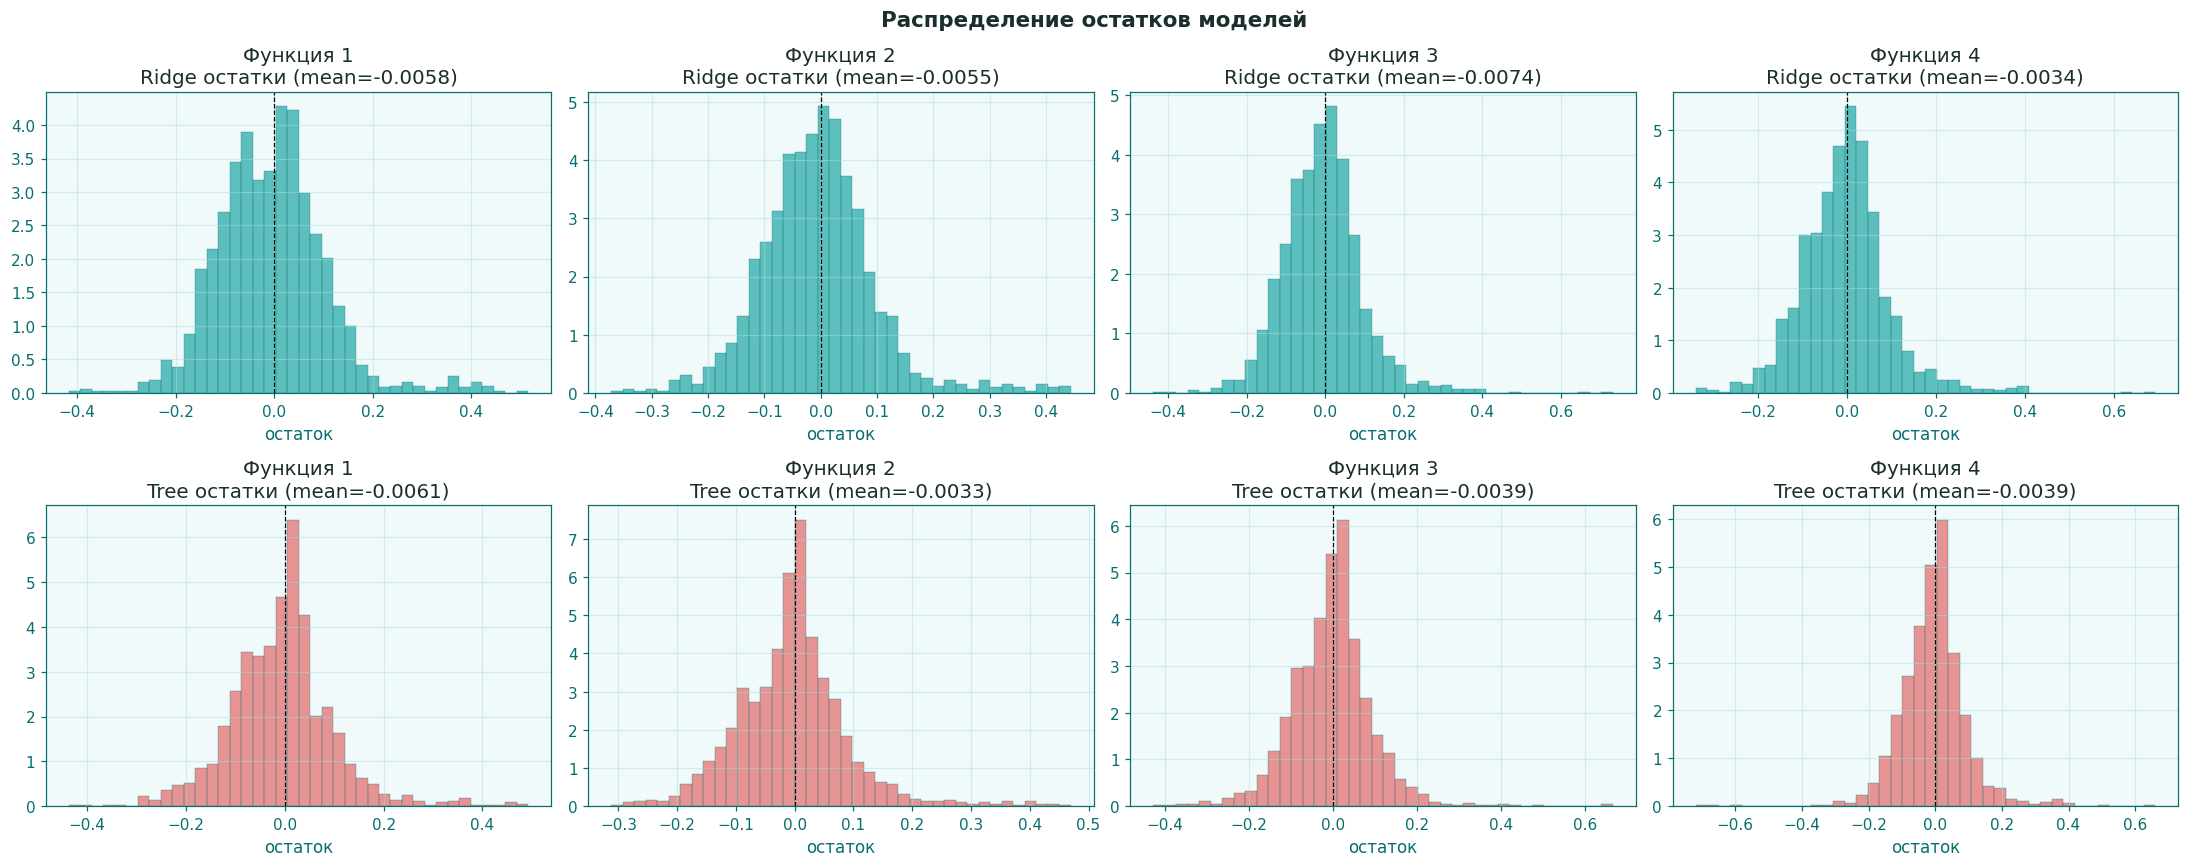

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (r, label_short) in enumerate(zip(all_results, labels)):
    ax = axes[0, i]
    residuals_ridge = r["y_test"] - r["y_pred_ridge"]
    ax.hist(
        residuals_ridge,
        bins=40,
        density=True,
        alpha=0.65,
        color=COLORS_4[0],
        edgecolor=TEAL_DARK,
        linewidth=0.3,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{label_short}\nRidge остатки (mean={residuals_ridge.mean():.4f})")
    ax.set_xlabel("остаток")

    ax = axes[1, i]
    residuals_tree = r["y_test"] - r["y_pred_tree"]
    ax.hist(
        residuals_tree,
        bins=40,
        density=True,
        alpha=0.65,
        color=COLORS_4[1],
        edgecolor=TEAL_DARK,
        linewidth=0.3,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{label_short}\nTree остатки (mean={residuals_tree.mean():.4f})")
    ax.set_xlabel("остаток")

plt.suptitle("Распределение остатков моделей", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Комбинированная модель: все фичи из всех 4 функций
# ============================================================
print("=== Комбинированная модель: все признаки ===")

# 1. Определяем общие ключи для merge (все кроме фичей)
base_cols = ["ID", "center_lon", "center_lat", "datetime", "noise"]
# берём только те base_cols, которые реально есть в features_1
base_cols = [c for c in base_cols if c in features_1.columns]

# 2. Начинаем с features_1 и последовательно присоединяем фичи из 2, 3, 4
combined_df = features_1.copy()

for df_features, new_cols in [
    (features_2, new_cols_2),
    (features_3, new_cols_3),
    (features_4, new_cols_4),
]:
    # Берём только те колонки-ключи + новые фичи, которые реально есть в df_features
    cols_to_add = [c for c in new_cols if c in df_features.columns]
    merge_cols = base_cols + cols_to_add
    # Оставляем только уникальные колонки (на случай пересечений)
    merge_cols = list(dict.fromkeys(merge_cols))
    combined_df = combined_df.merge(
        df_features[merge_cols],
        on=base_cols,
        how="outer",  # outer — чтобы не потерять строки
        suffixes=("", "_dup"),
    )
    # Удаляем дубликаты-суффиксы, если появились
    dup_cols = [c for c in combined_df.columns if c.endswith("_dup")]
    combined_df.drop(columns=dup_cols, inplace=True, errors="ignore")

# 3. Формируем список фичей — ТОЛЬКО те, что реально существуют в combined_df
all_feature_cols = list(set(new_cols_1 + new_cols_2 + new_cols_3 + new_cols_4))
all_feature_cols = [c for c in all_feature_cols if c in combined_df.columns]
print(f"Фичей из всех 4 наборов (реально в combined_df): {len(all_feature_cols)}")

# 4. Обучаем комбинированную модель
combined_results = train_and_evaluate(
    combined_df, all_feature_cols, target_col="noise", label="Все признаки (комбинация)"
)

print(
    f"Признаков: {combined_results['n_features']}, "
    f"Train: {combined_results['n_samples_train']}, "
    f"Test: {combined_results['n_samples_test']}"
)
print(
    f"\nRidge:       R2={combined_results['ridge_r2']:.4f}, "
    f"MAE={combined_results['ridge_mae']:.4f}, "
    f"RMSE={combined_results['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={combined_results['tree_r2']:.4f}, "
    f"MAE={combined_results['tree_mae']:.4f}, "
    f"RMSE={combined_results['tree_rmse']:.4f}"
)

# 5. Добавляем в сравнительную таблицу
combined_row = pd.DataFrame(
    [
        {
            "Признаки": combined_results["label"],
            "Кол-во фичей": combined_results["n_features"],
            "Train размер": combined_results["n_samples_train"],
            "Test размер": combined_results["n_samples_test"],
            "Ridge R2": combined_results["ridge_r2"],
            "Ridge MAE": combined_results["ridge_mae"],
            "Ridge RMSE": combined_results["ridge_rmse"],
            "Tree R2": combined_results["tree_r2"],
            "Tree MAE": combined_results["tree_mae"],
            "Tree RMSE": combined_results["tree_rmse"],
        }
    ]
)
comparison_full = pd.concat([comparison, combined_row], ignore_index=True)
print("\nПолная сравнительная таблица:")
print(comparison_full.to_string(index=False))

=== Комбинированная модель: все признаки ===
Фичей из всех 4 наборов (реально в combined_df): 910
Признаков: 910, Train: 6236, Test: 1559

Ridge:       R2=0.3567, MAE=0.0690, RMSE=0.0961
DecisionTree: R2=0.3884, MAE=0.0669, RMSE=0.0937

Полная сравнительная таблица:
                 Признаки  Кол-во фичей  Train размер  Test размер  Ridge R2  Ridge MAE  Ridge RMSE  Tree R2  Tree MAE  Tree RMSE
 Функция 1 (nearest hour)            10          6218         1555  0.189577   0.084076    0.111045 0.280283  0.075660   0.104646
Функция 2 (rolling 1-14d)           180          6218         1555  0.314480   0.075048    0.102130 0.404662  0.067594   0.095175
    Функция 3 (lags 2-5d)           120          6200         1551  0.251405   0.075648    0.102444 0.337900  0.069185   0.096344
    Функция 4 (day/night)           600          6191         1548  0.308977   0.071509    0.098698 0.291527  0.068988   0.099936
Все признаки (комбинация)           910          6236         1559  0.356666   0.06

Топ-20 признаков (комбинированная модель DecisionTree):
total_evaporation_hourly_day_mean_last_14d                       0.495453
v_component_of_wind_10m_night_max_last_14d                       0.082704
evaporation_from_vegetation_transpiration_hourly_mean_last_5d    0.073148
v_component_of_wind_10m_day_min_last_2d                          0.047797
total_evaporation_hourly_mean_last_5d                            0.046454
evaporation_from_vegetation_transpiration_hourly_min_lag3        0.043996
total_precipitation_hourly_day_mean_last_5d                      0.043353
skin_temperature_mean_last_10d                                   0.021858
total_evaporation_hourly_night_min_last_10d                      0.020690
surface_solar_radiation_downwards_hourly_max_last_7d             0.019140
temperature_2m_night_mean_last_14d                               0.018072
v_component_of_wind_10m_max_last_14d                             0.011993
volumetric_soil_water_layer_1_night_min_last_7d         

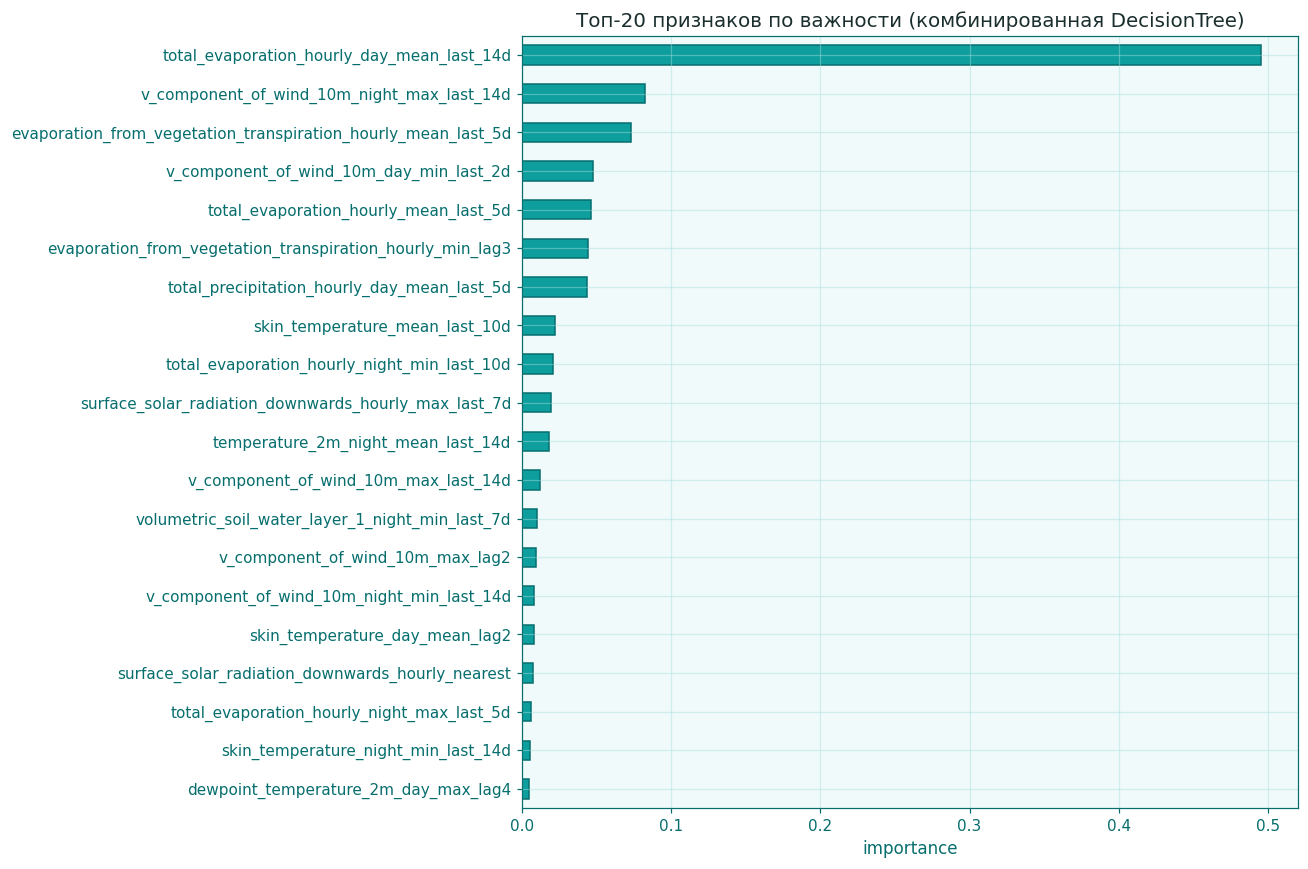

In [31]:
all_importances = pd.Series(
    combined_results["tree_model"].feature_importances_, index=all_feature_cols
).sort_values(ascending=False)
print("Топ-20 признаков (комбинированная модель DecisionTree):")
print(all_importances.head(20))

top_20_all = all_importances.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
top_20_all.sort_values().plot(kind="barh", ax=ax, color=TEAL, edgecolor=TEAL_DARK)
ax.set_title("Топ-20 признаков по важности (комбинированная DecisionTree)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

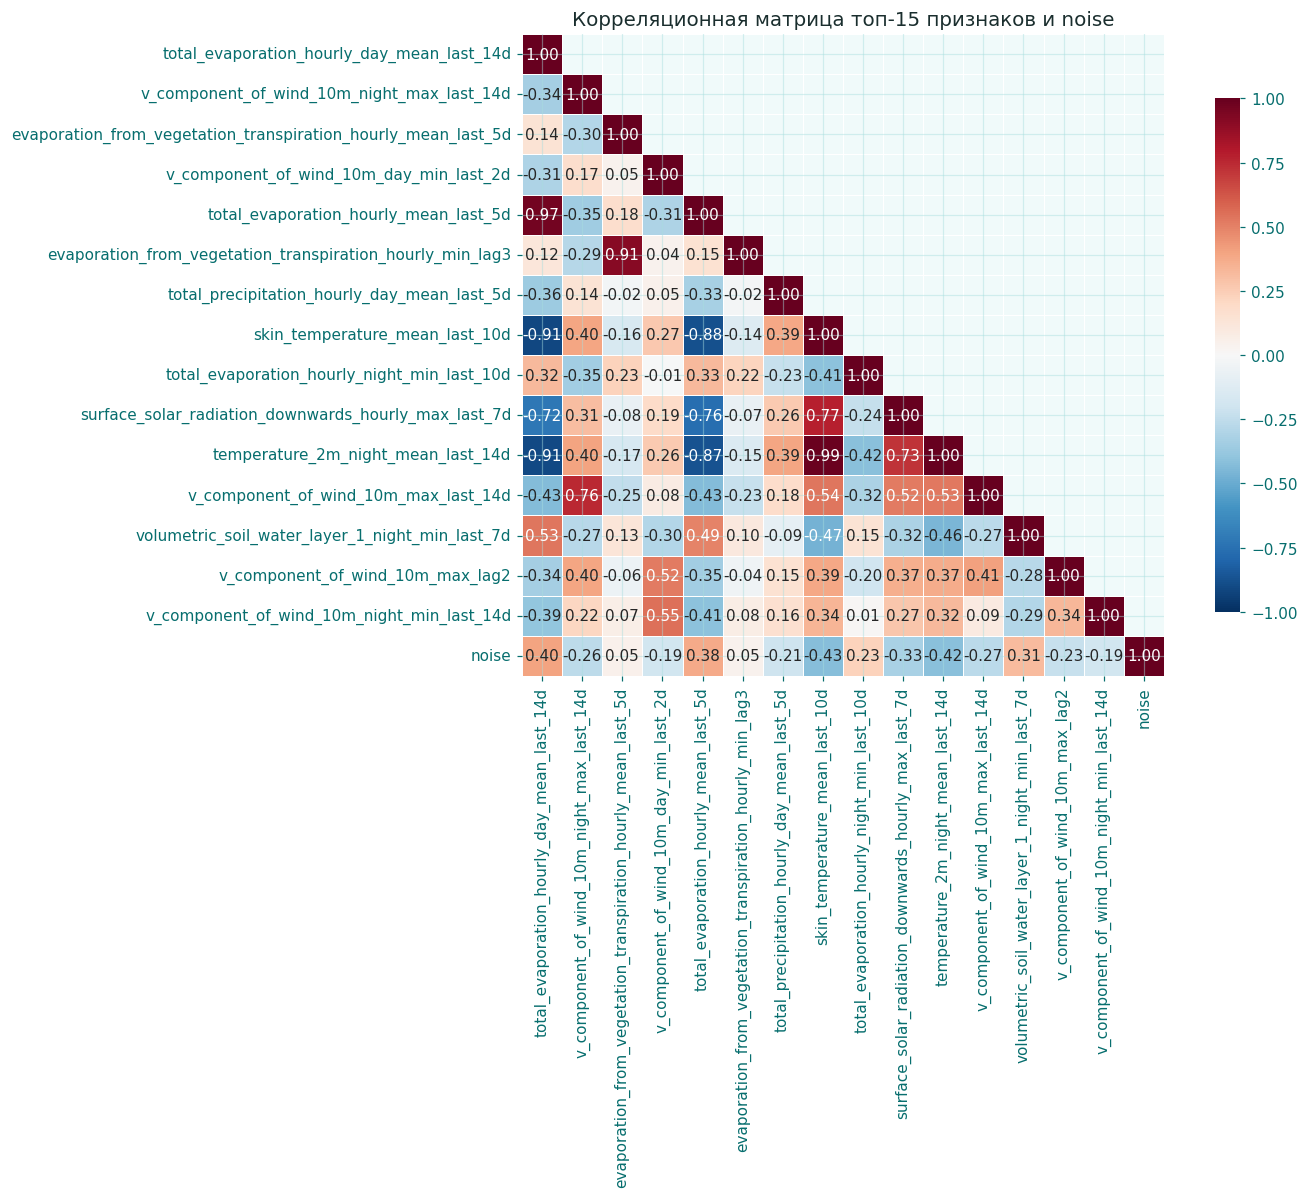

In [32]:
top_features = all_importances.head(15).index.tolist()
corr_cols = top_features + ["noise"]
corr_data = combined_df[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Корреляционная матрица топ-15 признаков и noise", fontsize=13)
plt.tight_layout()
plt.show()

## Финальные выводы

### Идея исследования
Данное исследование направлено на выявление степени объяснимости «физического шума» NDVI погодными условиями. Шум определяется как отклонение сырого значения NDVI (вычисленного по каналам B8 и B4 Landsat) от сглаженной кривой-эталона, построенной по алгоритму Влада и Миши (зимний базовый уровень, фильтр Prophet, удаление близких точек, перенос локальных минимумов, PCHIP-интерполяция, верхняя огибающая Savitzky-Golay).

# соединить все

In [33]:
try:
    snap_base
except NameError:
    # Восстанавливаем snap_base по образцу из ноутбука
    landsat_coords = pd.read_csv("landsat_data_2019_2025.csv")
    coord_lookup = (
        landsat_coords.groupby("ID")[["center_lon", "center_lat"]].first().reset_index()
    )
    snap_base = ndvi_all[
        ["ID", "datetime_utc", "NDVI_raw", "NDVI_smooth", "noise"]
    ].copy()
    snap_base["datetime_str_utc"] = snap_base["datetime_utc"].dt.strftime(
        "%Y-%m-%d %H:%M:%S"
    )
    snap_base = snap_base.merge(coord_lookup, on="ID", how="left")
    print("snap_base создан заново")

In [36]:
features_1.shape

(7782, 18)

In [37]:
features_2.shape

(7782, 188)

In [38]:
features_3.shape

(7782, 128)

In [39]:
features_4.shape

(7782, 608)

In [42]:
len(new_cols_3)

120

In [52]:
# Объединяем все признаки в один датафрейм
features_all = pd.concat([features_1, features_2, features_3, features_4], axis=1)
feature_cols_all = (
    new_cols_1 + new_cols_2 + new_cols_3 + new_cols_4
)  # set(features_all.columns)

# Обучаем модели
results_all = train_and_evaluate(
    features_all, feature_cols_all, label="Все признаки (1+2+3+4)"
)

print(f"\n=== Результаты: {results_all['label']} ===")
print(
    f"Признаков: {results_all['n_features']}, Train: {results_all['n_samples_train']}, Test: {results_all['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_all['ridge_r2']:.4f}, MAE={results_all['ridge_mae']:.4f}, RMSE={results_all['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_all['tree_r2']:.4f}, MAE={results_all['tree_mae']:.4f}, RMSE={results_all['tree_rmse']:.4f}"
)


=== Результаты: Все признаки (1+2+3+4) ===
Признаков: 910, Train: 6191, Test: 1548

Ridge:       R2=0.3292, MAE=0.0705, RMSE=0.0972
DecisionTree: R2=0.3489, MAE=0.0682, RMSE=0.0958


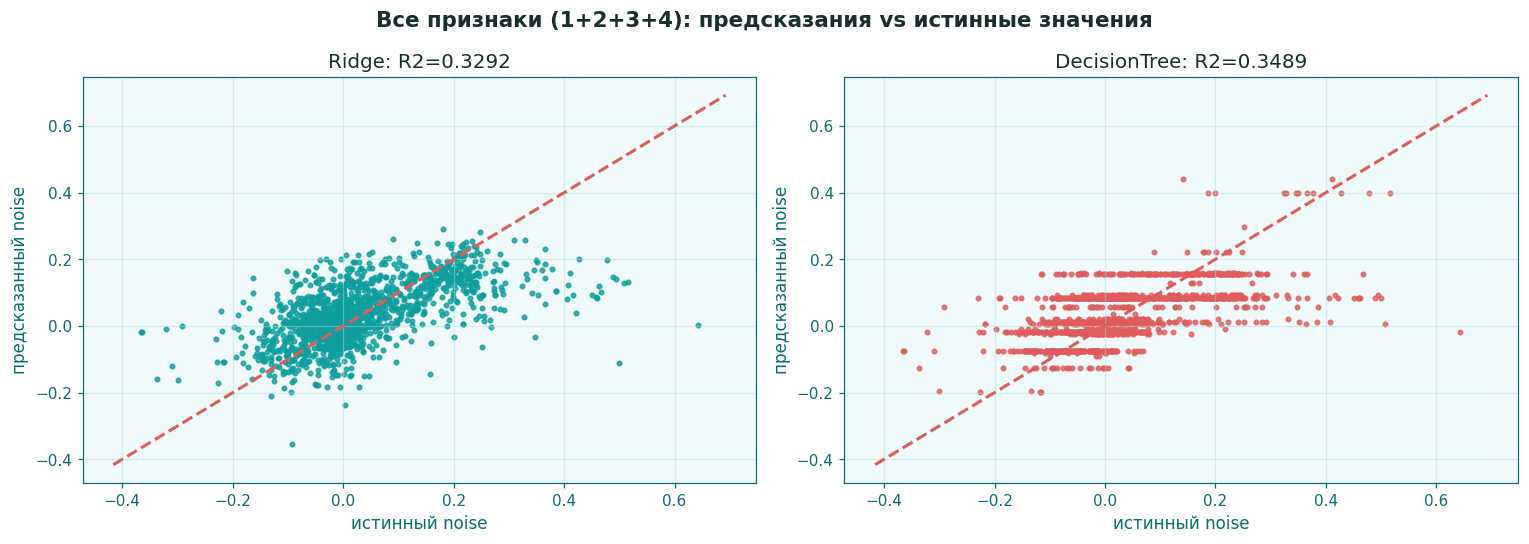

In [51]:
# Графики предсказаний
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_all["y_test"],
    results_all["y_pred_ridge"],
    alpha=0.3,
    s=8,
    color=COLORS_4[0],
)
lims = [results_all["y_test"].min() - 0.05, results_all["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge: R2={results_all['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_all["y_test"], results_all["y_pred_tree"], alpha=0.3, s=8, color=COLORS_4[1]
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree: R2={results_all['tree_r2']:.4f}")

plt.suptitle(
    f"{results_all['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Топ-20 признаков по важности (DecisionTree):
temperature_2m_night_mean_last_14d                                   0.510240
v_component_of_wind_10m_night_max_last_14d                           0.087465
evaporation_from_vegetation_transpiration_hourly_day_min_last_14d    0.083360
total_precipitation_hourly_night_mean_last_10d                       0.045445
volumetric_soil_water_layer_1_night_min_last_10d                     0.039514
evaporation_from_vegetation_transpiration_hourly_night_min_lag2      0.038220
total_evaporation_hourly_night_min_last_10d                          0.023336
temperature_2m_mean_last_14d                                         0.021535
total_precipitation_hourly_day_mean_lag3                             0.020200
total_evaporation_hourly_day_mean_last_14d                           0.016720
skin_temperature_min_last_10d                                        0.016200
dewpoint_temperature_2m_mean_lag3                                    0.012303
total_evaporation_h

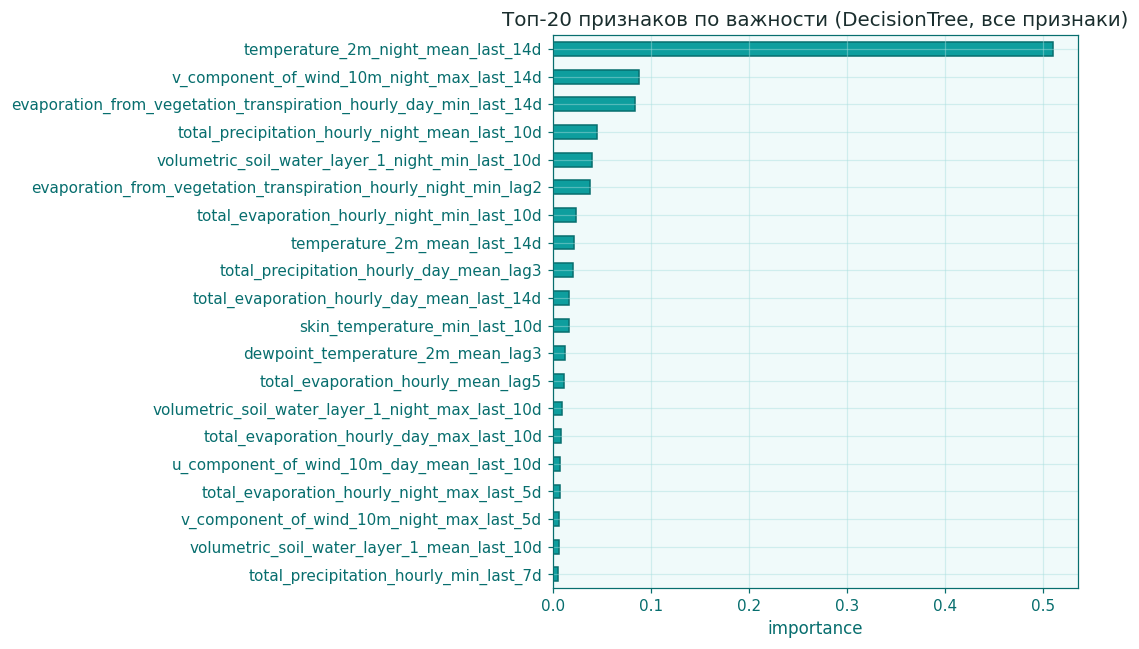

In [45]:
# Важность признаков для DecisionTree
importances_all = pd.Series(
    results_all["tree_model"].feature_importances_, index=feature_cols_all
).sort_values(ascending=False)

print("Топ-20 признаков по важности (DecisionTree):")
print(importances_all.head(20))

# Визуализация топ-20
top_20_all = importances_all.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_20_all.sort_values().plot(kind="barh", ax=ax, color=TEAL, edgecolor=TEAL_DARK)
ax.set_title("Топ-20 признаков по важности (DecisionTree, все признаки)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

# 5 самых важных признаков

In [46]:
# Получаем топ-5 самых важных признаков из предыдущего обучения
top5_features = importances_all.head(5).index.tolist()
print("Топ-5 признаков по важности:")
for i, f in enumerate(top5_features, 1):
    print(f"{i}. {f}")

Топ-5 признаков по важности:
1. temperature_2m_night_mean_last_14d
2. v_component_of_wind_10m_night_max_last_14d
3. evaporation_from_vegetation_transpiration_hourly_day_min_last_14d
4. total_precipitation_hourly_night_mean_last_10d
5. volumetric_soil_water_layer_1_night_min_last_10d


In [59]:
features_all = pd.concat([features_4], axis=1)

In [61]:
# Обучаем модель только на этих 5 признаках
results_top5 = train_and_evaluate(features_all, top5_features, label="Топ-5 признаков")

print(f"\n=== Результаты: {results_top5['label']} ===")
print(
    f"Признаков: {results_top5['n_features']}, Train: {results_top5['n_samples_train']}, Test: {results_top5['n_samples_test']}"
)
print(
    f"\nRidge:       R2={results_top5['ridge_r2']:.4f}, MAE={results_top5['ridge_mae']:.4f}, RMSE={results_top5['ridge_rmse']:.4f}"
)
print(
    f"DecisionTree: R2={results_top5['tree_r2']:.4f}, MAE={results_top5['tree_mae']:.4f}, RMSE={results_top5['tree_rmse']:.4f}"
)


=== Результаты: Топ-5 признаков ===
Признаков: 5, Train: 6218, Test: 1555

Ridge:       R2=0.1977, MAE=0.0846, RMSE=0.1105
DecisionTree: R2=0.3870, MAE=0.0699, RMSE=0.0966


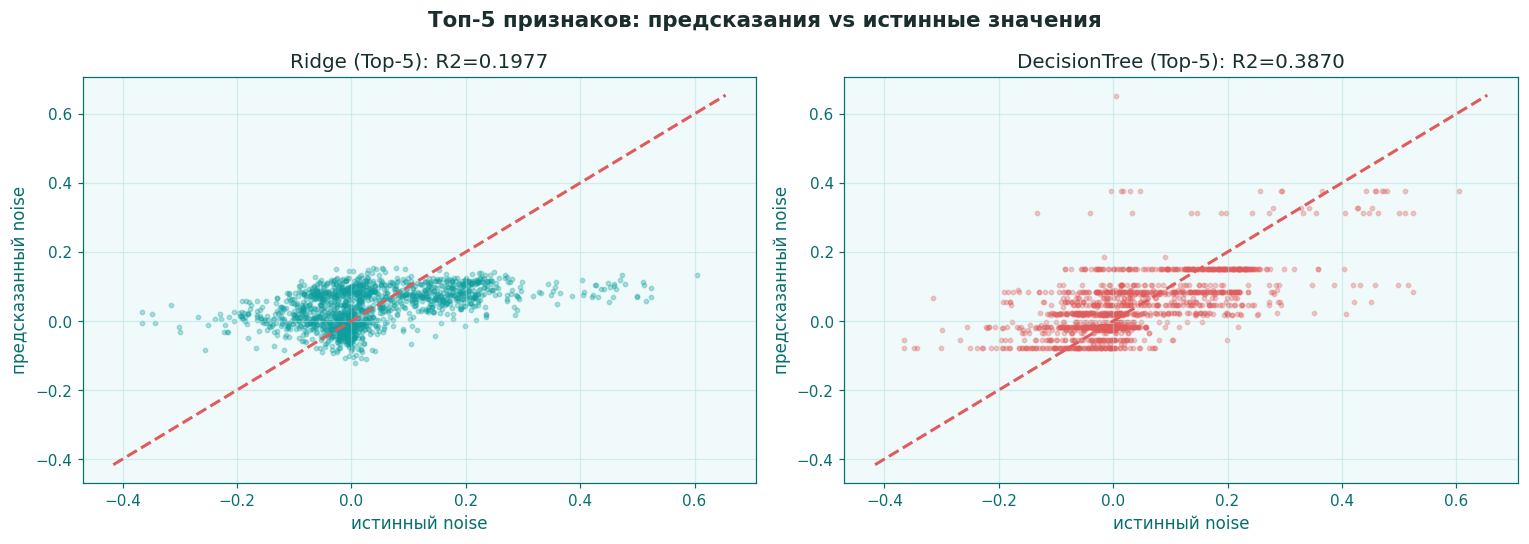

In [62]:
# Графики предсказаний для топ-5 признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(
    results_top5["y_test"],
    results_top5["y_pred_ridge"],
    alpha=0.3,
    s=8,
    color=COLORS_4[0],
)
lims = [results_top5["y_test"].min() - 0.05, results_top5["y_test"].max() + 0.05]
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"Ridge (Top-5): R2={results_top5['ridge_r2']:.4f}")

ax = axes[1]
ax.scatter(
    results_top5["y_test"],
    results_top5["y_pred_tree"],
    alpha=0.3,
    s=8,
    color=COLORS_4[1],
)
ax.plot(lims, lims, color=ACCENT, linewidth=2, linestyle="--")
ax.set_xlabel("истинный noise")
ax.set_ylabel("предсказанный noise")
ax.set_title(f"DecisionTree (Top-5): R2={results_top5['tree_r2']:.4f}")

plt.suptitle(
    f"{results_top5['label']}: предсказания vs истинные значения",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [63]:
def train_and_evaluate(df, feature_cols, target_col="noise", label=""):
    """Универсальная функция обучения и оценки Ridge + DecisionTree."""
    df_clean = df.dropna(subset=feature_cols + [target_col])
    X = df_clean[feature_cols].values
    y = df_clean[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Imputer + Scaler
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train)
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_imp = imputer.transform(X_test)
    X_test_sc = scaler.transform(X_test_imp)

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_sc, y_train)
    y_pred_ridge = ridge.predict(X_test_sc)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

    # DecisionTree
    tree = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree.fit(X_train_imp, y_train)  # tree не требует масштабирования
    y_pred_tree = tree.predict(X_test_imp)
    r2_tree = r2_score(y_test, y_pred_tree)
    mae_tree = mean_absolute_error(y_test, y_pred_tree)
    rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

    results = {
        "label": label,
        "n_features": len(feature_cols),
        "n_samples_train": len(y_train),
        "n_samples_test": len(y_test),
        "ridge_r2": r2_ridge,
        "ridge_mae": mae_ridge,
        "ridge_rmse": rmse_ridge,
        "tree_r2": r2_tree,
        "tree_mae": mae_tree,
        "tree_rmse": rmse_tree,
        "y_test": y_test,
        "y_pred_ridge": y_pred_ridge,
        "y_pred_tree": y_pred_tree,
        "ridge_model": ridge,
        "tree_model": tree,
        "feature_cols": feature_cols,
    }
    return results


print("вспомогательная функция train_and_evaluate определена")

вспомогательная функция train_and_evaluate определена
